#**Laboratorul 7**

Exercitiul 1:

In [1]:
import torch

a = torch.rand(5)
print(a)

b = torch.rand(3,4)
print(b)

c = torch.rand(2,3,4)
print(c)

tensor([0.6267, 0.4530, 0.1441, 0.0338, 0.3794])
tensor([[0.7183, 0.2373, 0.8279, 0.5043],
        [0.1676, 0.9994, 0.6179, 0.3222],
        [0.7019, 0.2799, 0.2162, 0.3076]])
tensor([[[3.2498e-01, 2.2692e-01, 5.3194e-02, 6.7739e-01],
         [5.8652e-01, 8.0266e-01, 1.1766e-01, 7.6234e-01],
         [6.7106e-01, 9.4468e-01, 2.7207e-01, 1.1584e-01]],

        [[9.8428e-01, 4.8276e-01, 3.1789e-01, 8.4975e-01],
         [2.7803e-01, 2.2504e-01, 1.6308e-04, 4.7621e-01],
         [6.5485e-02, 5.0414e-01, 7.0586e-01, 5.2671e-01]]])


Exercitiul 2

In [2]:
import torch

input = torch.tensor([-10,10,8],requires_grad=True,dtype = torch.float32)
sig = torch.nn.Sigmoid()
output = sig(input).sum()
output.backward()
print(input.grad)

tensor([4.5396e-05, 4.5417e-05, 3.3522e-04])


Exercitiul 3

In [3]:
A = torch.tensor([[1,2,-3],[4,5,10]])
B = torch.tensor([[10,11,-2],[13,-3,-8]])

H = A * B
a = 10
B_plus = B + a
A_T = A.T
B_T = B.T

print(H)
print(B_plus)
print(A_T)
print(B_T)

tensor([[ 10,  22,   6],
        [ 52, -15, -80]])
tensor([[20, 21,  8],
        [23,  7,  2]])
tensor([[ 1,  4],
        [ 2,  5],
        [-3, 10]])
tensor([[10, 13],
        [11, -3],
        [-2, -8]])


Exercitiul 4

In [4]:
A = torch.tensor([[1.,2.,3.],[4.,5.,6.]])
B = torch.tensor([[10.,11.],[-1.,0.],[1.,-3.]])

mult = torch.matmul(A,B)
print(mult)

A_Frob = torch.norm(A)
print(A_Frob)

B_Frob = torch.norm(B)
print(B_Frob)

tensor([[11.,  2.],
        [41., 26.]])
tensor(9.5394)
tensor(15.2315)


#**Laboratorul 8**

##Setul 1

Exercitiul 1

In [5]:
import torch
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
np.random.seed(42)

In [6]:
def synthetic_data(w, b, num_examples):
    """Generate y = Xw + b + noise."""
    X = torch.normal(0, 1, (num_examples, len(w)))
    y = X @ w + b
    y += torch.normal(0, 0.1, y.shape)#aici--------------------
    return X, y.reshape(-1, 1)

In [7]:
true_w = torch.tensor([0.15,-0.2,0.1])#aici--------------------
true_b = 0.2#aici----------------------------------------------
features, labels = synthetic_data(true_w, true_b, 2000)#aici---

In [8]:
print('Features:', features[0], '\nLabel:', labels[0])

Features: tensor([1.9269, 1.4873, 0.9007]) 
Label: tensor([0.2354])


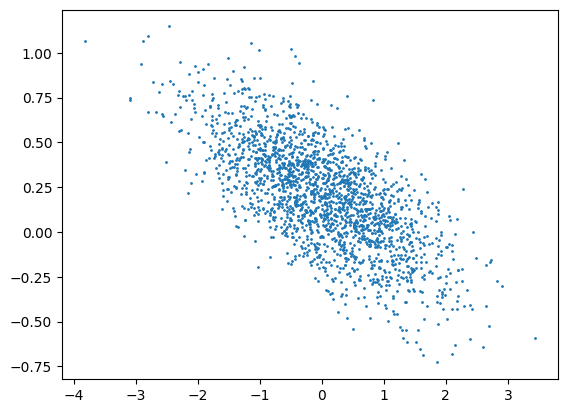

In [9]:
plt.scatter(features[:, 1].detach().numpy(), labels.detach().numpy(), s=1)
plt.show()

In [10]:
def data_iter(batch_size, features, labels):
    num_examples = len(features)
    indices = list(range(num_examples))
    # The examples are read at random, in no particular order
    np.random.shuffle(indices)
    for i in range(0, num_examples, batch_size):
        batch_indices = torch.tensor(
            indices[i: min(i + batch_size, num_examples)])
        yield features[batch_indices], labels[batch_indices]

In [11]:
def load_array(data_arrays, batch_size, is_train=True):
    """Construct a PyTorch data iterator."""
    dataset = torch.utils.data.TensorDataset(*data_arrays)
    return torch.utils.data.DataLoader(dataset, batch_size, shuffle=is_train)

In [12]:
batch_size = 20#aici------------------------------------------------------------------
data_iter = load_array((features, labels), batch_size)

In [13]:
import torch.nn as nn

class LinearRegression(nn.Module):
    def __init__(self, in_features, out_feature):
        super(LinearRegression, self).__init__()
        self.W = nn.Parameter(torch.randn(in_features, out_feature))
        self.b = nn.Parameter(torch.randn(out_feature))

    def forward(self, x):
        return x @ self.W + self.b
net = LinearRegression(3,1)

In [14]:
net.W.data.normal_(3.0)
net.b.data.fill_(3.0)

tensor([3.])

In [15]:
def lossFunction(y_in,y_pred_in):
  return (y_in - y_pred_in).pow(2).mean()

In [16]:
lr = 0.02
num_epochs = 40
for epoch in range(num_epochs):
    for X, y in data_iter:
        l = lossFunction(net(X), y)
        #optimizer.zero_grad()
        for param in net.parameters():
          param.grad.data.zero_() if param.grad is not None else None

        l.backward()

        #optimizer.step()
        for param in net.parameters():
          param.data -= lr * param.grad.data

    l = lossFunction(net(features), labels)
    print(f'Epoch {epoch + 1}, Loss {l:f}')

Epoch 1, Loss 0.016439
Epoch 2, Loss 0.009720
Epoch 3, Loss 0.009705
Epoch 4, Loss 0.009692
Epoch 5, Loss 0.009704
Epoch 6, Loss 0.009709
Epoch 7, Loss 0.009697
Epoch 8, Loss 0.009728
Epoch 9, Loss 0.009703
Epoch 10, Loss 0.009713
Epoch 11, Loss 0.009702
Epoch 12, Loss 0.009717
Epoch 13, Loss 0.009699
Epoch 14, Loss 0.009719
Epoch 15, Loss 0.009715
Epoch 16, Loss 0.009718
Epoch 17, Loss 0.009708
Epoch 18, Loss 0.009702
Epoch 19, Loss 0.009721
Epoch 20, Loss 0.009709
Epoch 21, Loss 0.009731
Epoch 22, Loss 0.009698
Epoch 23, Loss 0.009691
Epoch 24, Loss 0.009696
Epoch 25, Loss 0.009708
Epoch 26, Loss 0.009727
Epoch 27, Loss 0.009735
Epoch 28, Loss 0.009708
Epoch 29, Loss 0.009713
Epoch 30, Loss 0.009700
Epoch 31, Loss 0.009733
Epoch 32, Loss 0.009727
Epoch 33, Loss 0.009707
Epoch 34, Loss 0.009707
Epoch 35, Loss 0.009713
Epoch 36, Loss 0.009705
Epoch 37, Loss 0.009701
Epoch 38, Loss 0.009696
Epoch 39, Loss 0.009698
Epoch 40, Loss 0.009730


Exercitiul 2

In [17]:
import torchvision
from torchvision import transforms

# `ToTensor()` converts the image data from PIL type to 32-bit floating point
# tensors. It also divides all numbers by 255, so that all pixel values are between
# 0 and 1
trans = transforms.ToTensor()
mnist_train = torchvision.datasets.Imagenette(
    root="../data", transform=trans, download=True)
mnist_test = torchvision.datasets.Imagenette(
    root="../data", transform=trans, download=True)

100%|██████████| 1.56G/1.56G [00:28<00:00, 54.8MB/s]


In [18]:
def load_data_imagenette(batch_size, resize=(300,100)):
    """Download the Fashion-MNIST dataset and then load it into memory."""
    trans = [transforms.ToTensor()]
    if resize:
        trans.insert(0, transforms.Resize(resize))
    trans = transforms.Compose(trans)
    full_dataset = torchvision.datasets.Imagenette(
        root="../data",transform=trans, download=True)
    train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(full_dataset, [4456, 4456, 557],
                                                           generator=torch.Generator().manual_seed(42))
    return (
torch.utils.data.DataLoader(train_dataset, batch_size, shuffle=True,
                            num_workers=2),
            torch.utils.data.DataLoader(val_dataset, batch_size, shuffle=False,
                            num_workers=2),
            torch.utils.data.DataLoader(test_dataset, batch_size, shuffle=False,
                            num_workers=2))

In [19]:
batch_size = 100#aici-----------------------------------------------------------------------------
train_iter, val_iter, test_iter = load_data_imagenette(batch_size,resize=(300,100))

In [20]:
net = nn.Sequential(nn.Flatten(), nn.Linear(3 * 300 * 100, 10))

def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, std=0.01)

net.apply(init_weights)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=90000, out_features=10, bias=True)
)

In [21]:
loss = nn.CrossEntropyLoss()

In [22]:
lr = 0.1
optimizer = torch.optim.SGD(net.parameters(), lr=lr)

In [23]:
def evaluate_accuracy(net, data_iter):
    """Compute the accuracy for a model on a dataset."""
    net.eval()  # Set the model to evaluation mode

    total_loss = 0
    total_hits = 0
    total_samples = 0
    with torch.no_grad():
        for X, y in data_iter:
            y_hat = net(X)
            l = loss(y_hat, y)
            total_loss += float(l)
            total_hits += sum(net(X).argmax(axis=1).type(y.dtype) == y)
            total_samples += y.numel()
    return float(total_loss) / len(data_iter), float(total_hits) / total_samples  * 100

In [24]:
def train_epoch(net, train_iter, loss, optimizer):
    # Set the model to training mode
    net.train()
    # Sum of training loss, sum of training correct predictions, no. of examples
    total_loss = 0
    total_hits = 0
    total_samples = 0
    for X, y in train_iter:
        # Compute gradients and update parameters
        y_hat = net(X)
        l = loss(y_hat, y)
        # Using PyTorch built-in optimizer & loss criterion
        optimizer.zero_grad()
        l.backward()
        optimizer.step()
        total_loss += float(l)
        total_hits += sum(y_hat.argmax(axis=1).type(y.dtype) == y)
        total_samples += y.numel()
    # Return training loss and training accuracy
    return float(total_loss) / len(train_iter), float(total_hits) / total_samples  * 100

In [25]:
def train(net, train_iter, val_iter, loss, num_epochs, optimizer):
    """Train a model."""
    train_loss_all = []
    train_acc_all = []
    val_loss_all = []
    val_acc_all = []
    for epoch in range(num_epochs):
        train_loss, train_acc = train_epoch(net, train_iter, loss, optimizer)
        train_loss_all.append(train_loss)
        train_acc_all.append(train_acc)
        val_loss, val_acc = evaluate_accuracy(net, val_iter)
        val_loss_all.append(val_loss)
        val_acc_all.append(val_acc)
        print(f'Epoch {epoch + 1}, Train loss {train_loss:.2f}, Train accuracy {train_acc:.2f}, Validation loss {val_loss:.2f}, Validation accuracy {val_acc:.2f}')

    return train_loss_all, train_acc_all, val_loss_all, val_acc_all

In [26]:
num_epochs = 5
train_loss_all, train_acc_all, val_loss_all, val_acc_all = train(net, train_iter, val_iter, loss, num_epochs, optimizer)

/tmp/ipython-input-3329971113.py:16: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  total_loss += float(l)


Epoch 1, Train loss 538.44, Train accuracy 14.25, Validation loss 588.28, Validation accuracy 10.91
Epoch 2, Train loss 389.16, Train accuracy 18.49, Validation loss 335.45, Validation accuracy 19.37
Epoch 3, Train loss 375.79, Train accuracy 19.37, Validation loss 380.82, Validation accuracy 21.30
Epoch 4, Train loss 333.14, Train accuracy 21.59, Validation loss 357.18, Validation accuracy 23.05
Epoch 5, Train loss 280.77, Train accuracy 23.59, Validation loss 283.86, Validation accuracy 20.40


Exercitiul 3

In [27]:
import torchvision
from torchvision import transforms

# `ToTensor()` converts the image data from PIL type to 32-bit floating point
# tensors. It also divides all numbers by 255, so that all pixel values are between
# 0 and 1
trans = transforms.ToTensor()
mnist_train = torchvision.datasets.Imagenette(
    root="../data", transform=trans, download=True)
mnist_test = torchvision.datasets.Imagenette(
    root="../data", transform=trans, download=True)

In [28]:
def load_data_imagenette(batch_size, resize=(300,100)):
    """Download the Fashion-MNIST dataset and then load it into memory."""
    trans = [transforms.ToTensor()]
    if resize:
        trans.insert(0, transforms.Resize(resize))
    trans = transforms.Compose(trans)
    full_dataset = torchvision.datasets.Imagenette(
        root="../data",transform=trans, download=True)
    train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(full_dataset, [5000,4000,469],
                                                           generator=torch.Generator().manual_seed(42))
    return (
torch.utils.data.DataLoader(train_dataset, batch_size, shuffle=True,
                            num_workers=2),
            torch.utils.data.DataLoader(val_dataset, batch_size, shuffle=False,
                            num_workers=2),
            torch.utils.data.DataLoader(test_dataset, batch_size, shuffle=False,
                            num_workers=2))

In [29]:
batch_size = 150#aici-----------------------------------------------------------------------------
train_iter, val_iter, test_iter = load_data_imagenette(batch_size,resize=(300,100))

In [30]:
net = nn.Sequential(
    nn.Flatten(),
    nn.Linear(3*300*100, 128),
    nn.ReLU(),

    nn.Linear(128, 128),
    nn.ReLU(),

    nn.Linear(128, 128),
    nn.ReLU(),

    nn.Dropout(0.35),   # dupa al 3-lea hidden layer

    nn.Linear(128, 128),
    nn.ReLU(),

    nn.Linear(128, 128),
    nn.ReLU(),

    nn.Linear(128, 10)
)

def init_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.normal_(m.weight, mean=0.0, std=0.01)
        nn.init.zeros_(m.bias)

net.apply(init_weights)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=90000, out_features=128, bias=True)
  (2): ReLU()
  (3): Linear(in_features=128, out_features=128, bias=True)
  (4): ReLU()
  (5): Linear(in_features=128, out_features=128, bias=True)
  (6): ReLU()
  (7): Dropout(p=0.35, inplace=False)
  (8): Linear(in_features=128, out_features=128, bias=True)
  (9): ReLU()
  (10): Linear(in_features=128, out_features=128, bias=True)
  (11): ReLU()
  (12): Linear(in_features=128, out_features=10, bias=True)
)

In [31]:
loss = nn.CrossEntropyLoss()

In [32]:
lr = 0.15
optimizer = torch.optim.SGD(net.parameters(), lr=lr)

In [33]:
def evaluate_accuracy(net, data_iter):
    """Compute the accuracy for a model on a dataset."""
    net.eval()  # Set the model to evaluation mode

    total_loss = 0
    total_hits = 0
    total_samples = 0
    with torch.no_grad():
        for X, y in data_iter:
            y_hat = net(X)
            l = loss(y_hat, y)
            total_loss += float(l)
            total_hits += sum(net(X).argmax(axis=1).type(y.dtype) == y)
            total_samples += y.numel()
    return float(total_loss) / len(data_iter), float(total_hits) / total_samples  * 100

In [34]:
def train_epoch(net, train_iter, loss, optimizer):
    # Set the model to training mode
    net.train()
    # Sum of training loss, sum of training correct predictions, no. of examples
    total_loss = 0
    total_hits = 0
    total_samples = 0
    for X, y in train_iter:
        # Compute gradients and update parameters
        y_hat = net(X)
        l = loss(y_hat, y)
        # Using PyTorch built-in optimizer & loss criterion
        optimizer.zero_grad()
        l.backward()
        optimizer.step()
        total_loss += float(l)
        total_hits += sum(y_hat.argmax(axis=1).type(y.dtype) == y)
        total_samples += y.numel()
    # Return training loss and training accuracy
    return float(total_loss) / len(train_iter), float(total_hits) / total_samples  * 100

In [35]:
def train(net, train_iter, val_iter, loss, num_epochs, optimizer):
    """Train a model."""
    train_loss_all = []
    train_acc_all = []
    val_loss_all = []
    val_acc_all = []
    for epoch in range(num_epochs):
        train_loss, train_acc = train_epoch(net, train_iter, loss, optimizer)
        train_loss_all.append(train_loss)
        train_acc_all.append(train_acc)
        val_loss, val_acc = evaluate_accuracy(net, val_iter)
        val_loss_all.append(val_loss)
        val_acc_all.append(val_acc)
        print(f'Epoch {epoch + 1}, Train loss {train_loss:.2f}, Train accuracy {train_acc:.2f}, Validation loss {val_loss:.2f}, Validation accuracy {val_acc:.2f}')

    return train_loss_all, train_acc_all, val_loss_all, val_acc_all

In [36]:
num_epochs = 15
train_loss_all, train_acc_all, val_loss_all, val_acc_all = train(net, train_iter, val_iter, loss, num_epochs, optimizer)

Epoch 1, Train loss 2.30, Train accuracy 9.76, Validation loss 2.30, Validation accuracy 9.72
Epoch 2, Train loss 2.30, Train accuracy 10.24, Validation loss 2.30, Validation accuracy 9.72
Epoch 3, Train loss 2.30, Train accuracy 10.36, Validation loss 2.30, Validation accuracy 9.72
Epoch 4, Train loss 2.30, Train accuracy 10.42, Validation loss 2.30, Validation accuracy 9.72
Epoch 5, Train loss 2.30, Train accuracy 10.58, Validation loss 2.30, Validation accuracy 9.72
Epoch 6, Train loss 2.30, Train accuracy 10.36, Validation loss 2.30, Validation accuracy 9.90
Epoch 7, Train loss 2.30, Train accuracy 10.50, Validation loss 2.30, Validation accuracy 9.72
Epoch 8, Train loss 2.30, Train accuracy 10.22, Validation loss 2.30, Validation accuracy 9.72
Epoch 9, Train loss 2.30, Train accuracy 10.14, Validation loss 2.30, Validation accuracy 9.90
Epoch 10, Train loss 2.30, Train accuracy 10.18, Validation loss 2.30, Validation accuracy 9.72
Epoch 11, Train loss 2.30, Train accuracy 9.98, Va

##Setul 2

Exercitiul 1

In [37]:
import torch
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
np.random.seed(42)

In [38]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

# 1) Load data
data = fetch_openml(name="wine-quality-red", version=1, as_frame=True)
df = data.frame

X = df.drop("class", axis=1).values.astype(np.float32)   # (1599, 11)
y = df["class"].values.astype(np.float32)                # (1599,)

In [39]:
# 2) Split 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3) Standardizare: mean/std DOAR pe train
mu = X_train.mean(axis=0, keepdims=True)
sigma = X_train.std(axis=0, keepdims=True)
sigma[sigma == 0] = 1.0  # safety

X_train = (X_train - mu) / sigma
X_test  = (X_test - mu) / sigma

# 4) Torch tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train.reshape(-1, 1), dtype=torch.float32)
X_test_t  = torch.tensor(X_test, dtype=torch.float32)
y_test_t  = torch.tensor(y_test.reshape(-1, 1), dtype=torch.float32)

In [40]:
def load_array(data_arrays, batch_size, is_train=True):
    """Construct a PyTorch data iterator."""
    dataset = torch.utils.data.TensorDataset(*data_arrays)
    return torch.utils.data.DataLoader(dataset, batch_size, shuffle=is_train)

In [41]:
batch_size = 32
data_iter = load_array((features, labels), batch_size)

In [42]:
import torch.nn as nn

class LinearRegression(nn.Module):
    def __init__(self, in_features, out_feature):
        super(LinearRegression, self).__init__()
        self.W = nn.Parameter(torch.randn(in_features, out_feature))
        self.b = nn.Parameter(torch.randn(out_feature))

    def forward(self, x):
        return x @ self.W + self.b
net = LinearRegression(3,1)

In [43]:
def lossFunction(y_in,y_pred_in):
  return (y_in - y_pred_in).pow(2).mean()

In [44]:
num_epochs = 40
lr = 0.01
for epoch in range(num_epochs):
    for X, y in data_iter:
        l = lossFunction(net(X), y)
        #optimizer.zero_grad()
        for param in net.parameters():
            param.grad.data.zero_() if param.grad is not None else None

        l.backward()
        #optimizer.step()
        for param in net.parameters():
            param.data -= lr * param.grad.data

    l = lossFunction(net(features), labels)
    print(f'Epoch {epoch + 1}, Loss {l:f}')

Epoch 1, Loss 0.022876
Epoch 2, Loss 0.010926
Epoch 3, Loss 0.009784
Epoch 4, Loss 0.009698
Epoch 5, Loss 0.009690
Epoch 6, Loss 0.009692
Epoch 7, Loss 0.009691
Epoch 8, Loss 0.009691
Epoch 9, Loss 0.009694
Epoch 10, Loss 0.009692
Epoch 11, Loss 0.009691
Epoch 12, Loss 0.009691
Epoch 13, Loss 0.009694
Epoch 14, Loss 0.009692
Epoch 15, Loss 0.009690
Epoch 16, Loss 0.009692
Epoch 17, Loss 0.009692
Epoch 18, Loss 0.009692
Epoch 19, Loss 0.009692
Epoch 20, Loss 0.009691
Epoch 21, Loss 0.009692
Epoch 22, Loss 0.009692
Epoch 23, Loss 0.009691
Epoch 24, Loss 0.009690
Epoch 25, Loss 0.009693
Epoch 26, Loss 0.009691
Epoch 27, Loss 0.009695
Epoch 28, Loss 0.009690
Epoch 29, Loss 0.009690
Epoch 30, Loss 0.009691
Epoch 31, Loss 0.009695
Epoch 32, Loss 0.009695
Epoch 33, Loss 0.009691
Epoch 34, Loss 0.009691
Epoch 35, Loss 0.009691
Epoch 36, Loss 0.009694
Epoch 37, Loss 0.009693
Epoch 38, Loss 0.009691
Epoch 39, Loss 0.009691
Epoch 40, Loss 0.009695


Exercitiul 2

In [45]:
import torchvision
from torchvision import transforms

# `ToTensor()` converts the image data from PIL type to 32-bit floating point
# tensors. It also divides all numbers by 255, so that all pixel values are between
# 0 and 1
trans = transforms.ToTensor()
mnist_train = torchvision.datasets.OxfordIIITPet(
    root="../data", transform=trans, download=True)
mnist_test = torchvision.datasets.OxfordIIITPet(
    root="../data", transform=trans, download=True)

100%|██████████| 792M/792M [00:42<00:00, 18.7MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 13.9MB/s]


In [46]:
def load_data_oxford(batch_size, resize=(64,64)):
    """Download the Fashion-MNIST dataset and then load it into memory."""
    trans = [transforms.ToTensor()]
    if resize:
        trans.insert(0, transforms.Resize(resize))
    trans = transforms.Compose(trans)
    mnist_train = torchvision.datasets.OxfordIIITPet(
        root="../data", split="trainval", target_types="category",transform=trans, download=True)
    mnist_test = torchvision.datasets.OxfordIIITPet(
        root="../data", split="test", target_types="category", transform=trans, download=True)

  #am adaugat cele variabile pt interval si am modificat mai sus adaugand split, target_typese si stegand train
    n = len(mnist_train)
    n_train = int(0.8 * n)#aici spunea ca trebuie 80% cu 20%
    n_val = n - n_train

    mnist_train, mnist_val = torch.utils.data.random_split(mnist_train, [n_train,n_val],
                                                           generator=torch.Generator().manual_seed(42))
    return (torch.utils.data.DataLoader(mnist_train, batch_size, shuffle=True,
                            num_workers=2),
            torch.utils.data.DataLoader(mnist_val, batch_size, shuffle=False,
                            num_workers=2),
            torch.utils.data.DataLoader(mnist_test, batch_size, shuffle=False,
                            num_workers=2))

In [47]:
batch_size = 64#aici
train_iter, val_iter, test_iter = load_data_oxford(batch_size,resize=(64,64))#aici

In [48]:
net = nn.Sequential(nn.Flatten(),
                    nn.Linear(3*64*64,512),#3 canale pt ca ii RGB si 64 x 64 pt ca atat ii rezolutia
                    nn.ReLU(),
                    nn.Dropout(0.10),#spune ce sunt in total 2 hiddens layers si spune ca dupa primul se face dropout

                    nn.Linear(512,256),
                    nn.ReLU(),
                    nn.Linear(256,37)#is 37 pt ca avem intervalul [0,36]
                    )

def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight,mean=0.0, std=0.01)
        nn.init.constant_(m.bias,0.0)

net.apply(init_weights)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=12288, out_features=512, bias=True)
  (2): ReLU()
  (3): Dropout(p=0.1, inplace=False)
  (4): Linear(in_features=512, out_features=256, bias=True)
  (5): ReLU()
  (6): Linear(in_features=256, out_features=37, bias=True)
)

In [49]:
def try_gpu(i=0):
    """Return gpu(i) if exists, otherwise return cpu()."""
    if torch.cuda.device_count() >= i + 1:
        return torch.device(f'cuda:{i}')
    return torch.device('cpu')

try_gpu(), try_gpu(0), try_gpu(1)

(device(type='cuda', index=0),
 device(type='cuda', index=0),
 device(type='cpu'))

In [50]:
loss = nn.CrossEntropyLoss()
lr = 0.001
optimizer = torch.optim.Adam(net.parameters(), lr=lr)#aici pt ca zice cu adam

In [51]:
def evaluate_accuracy(net, data_iter):
    """Compute the accuracy for a model on a dataset."""
    net.eval()  # Set the model to evaluation mode

    total_loss = 0
    total_hits = 0
    total_samples = 0
    with torch.no_grad():
        for X, y in data_iter:
            y_hat = net(X)
            l = loss(y_hat, y)
            total_loss += float(l)
            total_hits += sum(net(X).argmax(axis=1).type(y.dtype) == y)
            total_samples += y.numel()
    return float(total_loss) / len(data_iter), float(total_hits) / total_samples  * 100

In [52]:
def train_epoch(net, train_iter, loss, optimizer):
    # Set the model to training mode
    net.train()
    # Sum of training loss, sum of training correct predictions, no. of examples
    total_loss = 0
    total_hits = 0
    total_samples = 0
    for X, y in train_iter:
        # Compute gradients and update parameters
        y_hat = net(X)
        l = loss(y_hat, y)
        # Using PyTorch built-in optimizer & loss criterion
        optimizer.zero_grad()
        l.backward()
        optimizer.step()
        total_loss += float(l)
        total_hits += sum(y_hat.argmax(axis=1).type(y.dtype) == y)
        total_samples += y.numel()
    # Return training loss and training accuracy
    return float(total_loss) / len(train_iter), float(total_hits) / total_samples  * 100

In [53]:
def train(net, train_iter, val_iter, loss, num_epochs, optimizer):
    """Train a model."""
    train_loss_all = []
    train_acc_all = []
    val_loss_all = []
    val_acc_all = []
    for epoch in range(num_epochs):
        train_loss, train_acc = train_epoch(net, train_iter, loss, optimizer)
        train_loss_all.append(train_loss)
        train_acc_all.append(train_acc)
        val_loss, val_acc = evaluate_accuracy(net, val_iter)
        val_loss_all.append(val_loss)
        val_acc_all.append(val_acc)
        print(f'Epoch {epoch + 1}, Train loss {train_loss:.2f}, Train accuracy {train_acc:.2f}, Validation loss {val_loss:.2f}, Validation accuracy {val_acc:.2f}')

    return train_loss_all, train_acc_all, val_loss_all, val_acc_all

In [54]:
num_epochs = 15
train_loss_all, train_acc_all, val_loss_all, val_acc_all = train(net, train_iter, val_iter, loss, num_epochs, optimizer)

Epoch 1, Train loss 3.59, Train accuracy 3.50, Validation loss 3.49, Validation accuracy 4.21
Epoch 2, Train loss 3.48, Train accuracy 5.67, Validation loss 3.45, Validation accuracy 5.57
Epoch 3, Train loss 3.44, Train accuracy 5.81, Validation loss 3.43, Validation accuracy 8.56
Epoch 4, Train loss 3.44, Train accuracy 6.59, Validation loss 3.41, Validation accuracy 6.39
Epoch 5, Train loss 3.40, Train accuracy 6.62, Validation loss 3.42, Validation accuracy 5.57
Epoch 6, Train loss 3.37, Train accuracy 7.34, Validation loss 3.40, Validation accuracy 8.29
Epoch 7, Train loss 3.35, Train accuracy 7.17, Validation loss 3.40, Validation accuracy 7.20
Epoch 8, Train loss 3.33, Train accuracy 8.97, Validation loss 3.40, Validation accuracy 7.88
Epoch 9, Train loss 3.30, Train accuracy 9.44, Validation loss 3.37, Validation accuracy 8.56
Epoch 10, Train loss 3.27, Train accuracy 10.39, Validation loss 3.34, Validation accuracy 8.56
Epoch 11, Train loss 3.21, Train accuracy 11.48, Validatio

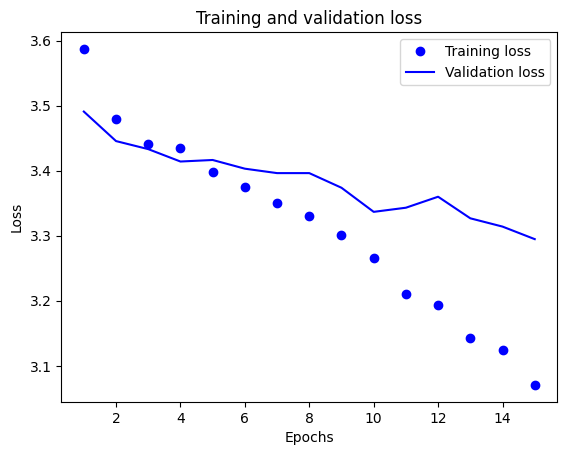

In [55]:
def plot_loss(train_loss_all, val_loss_all):
    epochs = range(1, len(train_loss_all) + 1)
    plt.plot(epochs, train_loss_all, 'bo', label='Training loss')
    plt.plot(epochs, val_loss_all, 'b', label='Validation loss')
    plt.title('Training and validation loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

plot_loss(train_loss_all, val_loss_all)

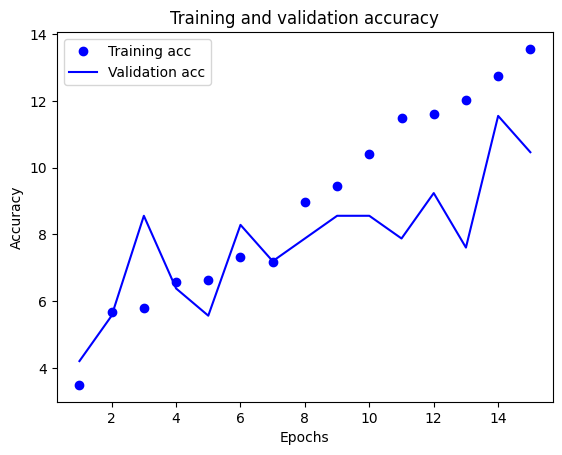

In [56]:
def plot_accuracy(train_acc_all, val_acc_all):
    epochs = range(1, len(train_acc_all) + 1)
    plt.plot(epochs, train_acc_all, 'bo', label='Training acc')
    plt.plot(epochs, val_acc_all, 'b', label='Validation acc')
    plt.title('Training and validation accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

plot_accuracy(train_acc_all, val_acc_all)

In [57]:
test_loss, test_acc = evaluate_accuracy(net, test_iter)
print(f'Test loss {test_loss:.2f}, Test accuracy {test_acc:.2f}')

Test loss 3.39, Test accuracy 8.20


Exercitiul 3

In [58]:
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader, random_split
import matplotlib.pyplot as plt

torch.manual_seed(42)

In [59]:
def load_data_synthetic_regression(batch_size, n=10_000):
    torch.manual_seed(42)

    # generezi X in [-2,2]^3
    X = -2 + 4 * torch.rand(n, 3)

    # zgomot e ~ N(0, 0.1^2)  (std=0.1)
    eps = torch.normal(mean=0.0, std=0.1, size=(n, 1))

    # y = sin(x0) + 0.5*x1^2 - x2 + e
    y = torch.sin(X[:, 0:1]) + 0.5 * (X[:, 1:2] ** 2) - X[:, 2:3] + eps

    dataset = TensorDataset(X, y)

    # split 70/15/15 ca la Oxford
    n_total = len(dataset)
    n_train = int(0.70 * n_total)
    n_val   = int(0.15 * n_total)
    n_test  = n_total - n_train - n_val

    train_ds, val_ds, test_ds = torch.utils.data.random_split(
        dataset, [n_train, n_val, n_test],
        generator=torch.Generator().manual_seed(42)
    )

    return (
        DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=2),
        DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=2),
        DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=2),
    )

In [60]:
batch_size = 64
train_iter, val_iter, test_iter = load_data_synthetic_regression(batch_size)

In [61]:
#4) Model: MLP cu 3 hidden layers, 64 unitati fiecare, ReLU, output 1
net = nn.Sequential(nn.Flatten(),
                    nn.Linear(3,64),
                    nn.ReLU(),
                    nn.Linear(64,64),
                    nn.ReLU(),
                    nn.Linear(64,64),
                    nn.ReLU(),
                    nn.Linear(64,1)
                    )
# Init: weight ~ N(0, 0.01), bias = 0
def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight,mean=0.0, std=0.01)
        nn.init.constant_(m.bias,0.0)

net.apply(init_weights)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=3, out_features=64, bias=True)
  (2): ReLU()
  (3): Linear(in_features=64, out_features=64, bias=True)
  (4): ReLU()
  (5): Linear(in_features=64, out_features=64, bias=True)
  (6): ReLU()
  (7): Linear(in_features=64, out_features=1, bias=True)
)

In [62]:
loss_fn = nn.MSELoss()

In [63]:
lr = 0.001
optimizer = torch.optim.Adam(net.parameters(), lr=lr)

In [64]:
def evaluate_regression(net, data_iter):
    net.eval()
    total_loss = 0.0
    with torch.no_grad():
        for Xb, yb in data_iter:
            pred = net(Xb)
            l = loss_fn(pred, yb)
            total_loss += float(l)
    return total_loss / len(data_iter)

In [65]:
def train_epoch_regression(net, train_iter, optimizer):
    net.train()
    total_loss = 0.0
    for Xb, yb in train_iter:
        pred = net(Xb)
        l = loss_fn(pred, yb)
        optimizer.zero_grad()
        l.backward()
        optimizer.step()
        total_loss += float(l)
    return total_loss / len(train_iter)

In [66]:
def train(net, train_iter, val_iter, num_epochs, optimizer):
    train_losses, val_losses = [], []
    for epoch in range(num_epochs):
        tr = train_epoch_regression(net, train_iter, optimizer)
        va = evaluate_regression(net, val_iter)
        train_losses.append(tr)
        val_losses.append(va)
        print(f"Epoch {epoch+1:02d} | train loss {tr:.4f} | val loss {va:.4f}")
    return train_losses, val_losses

In [67]:
num_epochs = 50
train_loss_all, val_loss_all= train(net, train_iter, val_iter, num_epochs, optimizer)

Epoch 01 | train loss 1.2713 | val loss 0.1948
Epoch 02 | train loss 0.0819 | val loss 0.0597
Epoch 03 | train loss 0.0493 | val loss 0.0445
Epoch 04 | train loss 0.0366 | val loss 0.0351
Epoch 05 | train loss 0.0293 | val loss 0.0309
Epoch 06 | train loss 0.0261 | val loss 0.0275
Epoch 07 | train loss 0.0236 | val loss 0.0233
Epoch 08 | train loss 0.0206 | val loss 0.0210
Epoch 09 | train loss 0.0181 | val loss 0.0186
Epoch 10 | train loss 0.0172 | val loss 0.0188
Epoch 11 | train loss 0.0152 | val loss 0.0155
Epoch 12 | train loss 0.0145 | val loss 0.0225
Epoch 13 | train loss 0.0141 | val loss 0.0142
Epoch 14 | train loss 0.0130 | val loss 0.0159
Epoch 15 | train loss 0.0130 | val loss 0.0133
Epoch 16 | train loss 0.0131 | val loss 0.0196
Epoch 17 | train loss 0.0130 | val loss 0.0150
Epoch 18 | train loss 0.0128 | val loss 0.0128
Epoch 19 | train loss 0.0130 | val loss 0.0172
Epoch 20 | train loss 0.0126 | val loss 0.0137
Epoch 21 | train loss 0.0127 | val loss 0.0172
Epoch 22 | tr

#**Laboratorul 9**

##Setul 1

Exercitiul 1

In [68]:
import torch
from torch import nn
from torch.nn import functional as F
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt

torch.manual_seed(42)
torch.backends.cudnn.deterministic = True

In [69]:
X = torch.rand(1, 1, 7, 7)
# Note that here 1 row or column is padded on either side, so a total of 2
# rows or columns are added
conv2d = nn.Conv2d(1, 1, kernel_size=4, padding=(2,1),stride=(3,3))#aci trebuie stabilit kernel size ul in functie de rezultat. L-am determinat prin incercari
conv2d(X).shape

torch.Size([1, 1, 3, 2])

Exercitiul 2

In [70]:
class Residual(nn.Module):
    """The Residual block of ResNet."""
    def __init__(self, input_channels, num_channels,
                 use_1x1conv=False, strides=1):
        super().__init__()
        self.conv1 = nn.Conv2d(input_channels, num_channels,
                               kernel_size=3, padding=1, stride=strides)
        self.bn1 = nn.BatchNorm2d(num_channels)
        self.conv2 = nn.Conv2d(num_channels, num_channels,
                               kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(num_channels)
        if use_1x1conv:
            self.conv3 = nn.Conv2d(input_channels, num_channels,
                                   kernel_size=1, stride=strides)
        else:
            self.conv3 = None

    def forward(self, X):
        Y = nn.ReLU()(self.bn1(self.conv1(X)))
        Y = self.bn2(self.conv2(Y))
        if self.conv3:
            X = self.conv3(X)
        Y += X
        return nn.ReLU()(Y)

In [71]:
def resnet_block(input_channels, num_channels, num_residuals,
                 first_block=False):
    blk = []
    for i in range(num_residuals):
        if i == 0 and not first_block:
            blk.append(Residual(input_channels, num_channels,
                                use_1x1conv=True, strides=2))
        else:
            blk.append(Residual(num_channels, num_channels))
    return blk

In [72]:
net = nn.Sequential(
    # stem (ResNet-like)
    nn.Conv2d(3, 16, kernel_size=3, padding=1, stride=1),
    nn.BatchNorm2d(16),
    nn.ReLU(),

    # module 1 (fără schimbare de rezoluție)
    Residual(16, 16),

    # downsample între module (poți lăsa și în blocul 2 cu stride=2)
    nn.AvgPool2d(kernel_size=2, stride=2),  # 32x32 -> 16x16

    # module 2 (schimbi canalele => ai nevoie de 1x1 conv pe skip)
    Residual(16, 32, use_1x1conv=True, strides=2),  # 16x16 -> 8x8

    # head
    nn.AdaptiveAvgPool2d((1, 1)),
    nn.Flatten(),
    nn.Linear(32, 10)
)

In [73]:
def load_data_svhn(batch_size, resize=(32,32)):
    """Download the Fashion-MNIST dataset and then load it into memory."""
    trans = [transforms.ToTensor()]
    if resize:
        trans.insert(0, transforms.Resize(resize))
    trans = transforms.Compose(trans)
    mnist_train = torchvision.datasets.SVHN(
        root="../data", split='train', transform=trans, download=True)
    mnist_test = torchvision.datasets.SVHN(
        root="../data", split='test', transform=trans, download=True)
    mnist_train, mnist_val = torch.utils.data.random_split(mnist_train, [43257, 30000],#aici split + interval
                                                           generator=torch.Generator().manual_seed(42))
    return (torch.utils.data.DataLoader(mnist_train, batch_size, shuffle=True,
                            num_workers=2),
            torch.utils.data.DataLoader(mnist_val, batch_size, shuffle=False,
                            num_workers=2),
            torch.utils.data.DataLoader(mnist_test, batch_size, shuffle=False,
                            num_workers=2))

In [74]:
def evaluate_accuracy(net, data_iter, loss, device):
    """Compute the accuracy for a model on a dataset."""
    net.eval()  # Set the model to evaluation mode

    total_loss = 0
    total_hits = 0
    total_samples = 0
    with torch.no_grad():
        for X, y in data_iter:
            X, y = X.to(device), y.to(device)
            y_hat = net(X)
            l = loss(y_hat, y)
            total_loss += float(l)
            total_hits += sum(net(X).argmax(axis=1).type(y.dtype) == y)
            total_samples += y.numel()
    return float(total_loss) / len(data_iter), float(total_hits) / total_samples  * 100

In [75]:
def train_epoch(net, train_iter, loss, optimizer, device):
    # Set the model to training mode
    net.train()
    # Sum of training loss, sum of training correct predictions, no. of examples
    total_loss = 0
    total_hits = 0
    total_samples = 0
    for X, y in train_iter:
        # Compute gradients and update parameters
        X, y = X.to(device), y.to(device)
        y_hat = net(X)
        l = loss(y_hat, y)
        # Using PyTorch built-in optimizer & loss criterion
        optimizer.zero_grad()
        l.backward()
        optimizer.step()
        total_loss += float(l)
        total_hits += sum(y_hat.argmax(axis=1).type(y.dtype) == y)
        total_samples += y.numel()
    # Return training loss and training accuracy
    return float(total_loss) / len(train_iter), float(total_hits) / total_samples  * 100

In [76]:
def train(net, train_iter, val_iter, test_iter, num_epochs, lr, device):
    """Train a model."""
    train_loss_all = []
    train_acc_all = []
    val_loss_all = []
    val_acc_all = []
    def init_weights(m):
        if type(m) == nn.Linear or type(m) == nn.Conv2d:
            nn.init.xavier_uniform_(m.weight)
    net.apply(init_weights)
    print('Training on', device)
    net.to(device)
    optimizer = torch.optim.SGD(net.parameters(), lr=lr)
    loss = nn.CrossEntropyLoss()
    for epoch in range(num_epochs):
        train_loss, train_acc = train_epoch(net, train_iter, loss, optimizer, device)
        train_loss_all.append(train_loss)
        train_acc_all.append(train_acc)
        val_loss, val_acc = evaluate_accuracy(net, val_iter, loss, device)
        val_loss_all.append(val_loss)
        val_acc_all.append(val_acc)
        print(f'Epoch {epoch + 1}, Train loss {train_loss:.2f}, Train accuracy {train_acc:.2f}, Validation loss {val_loss:.2f}, Validation accuracy {val_acc:.2f}')
    test_loss, test_acc = evaluate_accuracy(net, test_iter, loss, device)
    print(f'Test loss {test_loss:.2f}, Test accuracy {test_acc:.2f}')

    return train_loss_all, train_acc_all, val_loss_all, val_acc_all

In [77]:
def try_gpu(i=0):
    """Return gpu(i) if exists, otherwise return cpu()."""
    if torch.cuda.device_count() >= i + 1:
        return torch.device(f'cuda:{i}')
    return torch.device('cpu')

In [78]:
def plot_loss(train_loss_all, val_loss_all):
    epochs = range(1, len(train_loss_all) + 1)
    plt.plot(epochs, train_loss_all, 'bo', label='Training loss')
    plt.plot(epochs, val_loss_all, 'b', label='Validation loss')
    plt.title('Training and validation loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

In [79]:
def plot_accuracy(train_acc_all, val_acc_all):
    epochs = range(1, len(train_acc_all) + 1)
    plt.plot(epochs, train_acc_all, 'bo', label='Training acc')
    plt.plot(epochs, val_acc_all, 'b', label='Validation acc')
    plt.title('Training and validation accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

In [80]:
batch_size, lr, num_epochs = 256, 0.9, 10
train_iter, val_iter, test_iter = load_data_svhn(batch_size,resize=(32,32))
train_loss_all, train_acc_all, val_loss_all, val_acc_all = train(net, train_iter, val_iter, test_iter, num_epochs, lr, try_gpu()) #2 min

100%|██████████| 182M/182M [00:02<00:00, 62.9MB/s]
100%|██████████| 64.3M/64.3M [00:01<00:00, 54.4MB/s]


Training on cuda:0
Epoch 1, Train loss 2.08, Train accuracy 26.33, Validation loss 2.22, Validation accuracy 26.21
Epoch 2, Train loss 1.41, Train accuracy 53.21, Validation loss 1.41, Validation accuracy 53.49
Epoch 3, Train loss 0.86, Train accuracy 73.04, Validation loss 0.82, Validation accuracy 72.66
Epoch 4, Train loss 0.60, Train accuracy 81.69, Validation loss 0.65, Validation accuracy 79.02
Epoch 5, Train loss 0.48, Train accuracy 85.78, Validation loss 0.65, Validation accuracy 78.80
Epoch 6, Train loss 0.42, Train accuracy 87.36, Validation loss 0.50, Validation accuracy 84.18
Epoch 7, Train loss 0.38, Train accuracy 88.65, Validation loss 0.40, Validation accuracy 87.85
Epoch 8, Train loss 0.34, Train accuracy 89.65, Validation loss 0.48, Validation accuracy 84.74
Epoch 9, Train loss 0.33, Train accuracy 90.25, Validation loss 0.67, Validation accuracy 79.05
Epoch 10, Train loss 0.31, Train accuracy 90.61, Validation loss 0.50, Validation accuracy 84.66
Test loss 0.48, Test

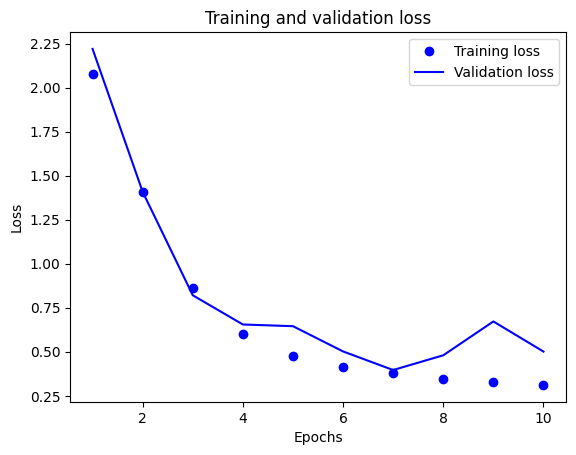

In [81]:
plot_loss(train_loss_all, val_loss_all)

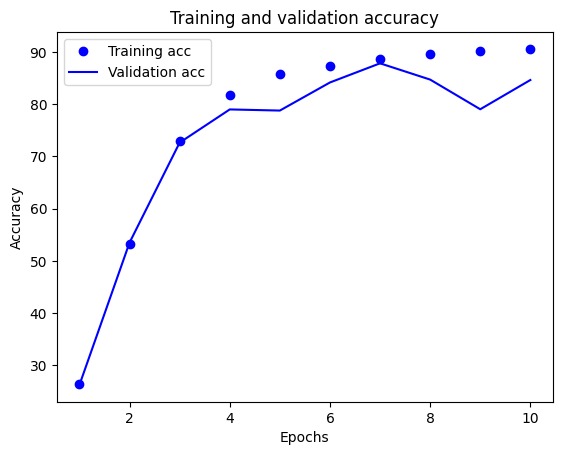

In [82]:
plot_accuracy(train_acc_all, val_acc_all)

Exercitiul 3

In [83]:
class ConvBlock(nn.Module):
  def __init__(self, in_channels=3):
    super().__init__()
    self.conv1 = nn.Conv2d(in_channels, 32, kernel_size=3, padding=1)
    self.relu1 = nn.ReLU()

    self.conv2 = nn.Conv2d(32, 3, kernel_size=1)
    self.bn2 = nn.BatchNorm2d(3)
    self.relu2 = nn.ReLU()

  def forward(self, x):
    y = self.relu1(self.conv1(x)) # y primește acum 32 de canale
    y = self.relu2(self.bn2(self.conv2(y))) # Aici, self.conv2 primește y (32 de canale)
    return x + y

In [84]:
net = nn.Sequential(
    ConvBlock(3),
    nn.Flatten(),
    nn.Linear(3*32*32,10)
    )

net

Sequential(
  (0): ConvBlock(
    (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (relu1): ReLU()
    (conv2): Conv2d(32, 3, kernel_size=(1, 1), stride=(1, 1))
    (bn2): BatchNorm2d(3, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu2): ReLU()
  )
  (1): Flatten(start_dim=1, end_dim=-1)
  (2): Linear(in_features=3072, out_features=10, bias=True)
)

In [85]:
def load_data_svhn(batch_size, resize=None):
    """Download the Fashion-MNIST dataset and then load it into memory."""
    trans = [transforms.ToTensor()]
    if resize:
        trans.insert(0, transforms.Resize(resize))
    trans = transforms.Compose(trans)
    mnist_train = torchvision.datasets.SVHN(
        root="../data", split="train", transform=trans, download=True)
    mnist_test = torchvision.datasets.SVHN(
        root="../data", split="test", transform=trans, download=True)
    mnist_train, mnist_val = torch.utils.data.random_split(mnist_train, [43257, 30000],
                                                           generator=torch.Generator().manual_seed(42))
    return (torch.utils.data.DataLoader(mnist_train, batch_size, shuffle=True,
                            num_workers=2),
            torch.utils.data.DataLoader(mnist_val, batch_size, shuffle=False,
                            num_workers=2),
            torch.utils.data.DataLoader(mnist_test, batch_size, shuffle=False,
                            num_workers=2))

In [86]:
def evaluate_accuracy(net, data_iter, loss, device):
    """Compute the accuracy for a model on a dataset."""
    net.eval()  # Set the model to evaluation mode

    total_loss = 0
    total_hits = 0
    total_samples = 0
    with torch.no_grad():
        for X, y in data_iter:
            X, y = X.to(device), y.to(device)
            y_hat = net(X)
            l = loss(y_hat, y)
            total_loss += float(l)
            total_hits += sum(net(X).argmax(axis=1).type(y.dtype) == y)
            total_samples += y.numel()
    return float(total_loss) / len(data_iter), float(total_hits) / total_samples  * 100

In [87]:
def train_epoch(net, train_iter, loss, optimizer, device):
    # Set the model to training mode
    net.train()
    # Sum of training loss, sum of training correct predictions, no. of examples
    total_loss = 0
    total_hits = 0
    total_samples = 0
    for X, y in train_iter:
        # Compute gradients and update parameters
        X, y = X.to(device), y.to(device)
        y_hat = net(X)
        l = loss(y_hat, y)
        # Using PyTorch built-in optimizer & loss criterion
        optimizer.zero_grad()
        l.backward()
        optimizer.step()
        total_loss += float(l)
        total_hits += sum(y_hat.argmax(axis=1).type(y.dtype) == y)
        total_samples += y.numel()
    # Return training loss and training accuracy
    return float(total_loss) / len(train_iter), float(total_hits) / total_samples  * 100

In [88]:
def train(net, train_iter, val_iter, test_iter, num_epochs, lr, device):
    """Train a model."""
    train_loss_all = []
    train_acc_all = []
    val_loss_all = []
    val_acc_all = []
    def init_weights(m):
        if type(m) == nn.Linear or type(m) == nn.Conv2d:
            nn.init.xavier_uniform_(m.weight)
    net.apply(init_weights)
    print('Training on', device)
    net.to(device)
    optimizer = torch.optim.SGD(net.parameters(), lr=lr)
    loss = nn.CrossEntropyLoss()
    for epoch in range(num_epochs):
        train_loss, train_acc = train_epoch(net, train_iter, loss, optimizer, device)
        train_loss_all.append(train_loss)
        train_acc_all.append(train_acc)
        val_loss, val_acc = evaluate_accuracy(net, val_iter, loss, device)
        val_loss_all.append(val_loss)
        val_acc_all.append(val_acc)
        print(f'Epoch {epoch + 1}, Train loss {train_loss:.2f}, Train accuracy {train_acc:.2f}, Validation loss {val_loss:.2f}, Validation accuracy {val_acc:.2f}')
    test_loss, test_acc = evaluate_accuracy(net, test_iter, loss, device)
    print(f'Test loss {test_loss:.2f}, Test accuracy {test_acc:.2f}')

    return train_loss_all, train_acc_all, val_loss_all, val_acc_all

In [89]:
def try_gpu(i=0):
    """Return gpu(i) if exists, otherwise return cpu()."""
    if torch.cuda.device_count() >= i + 1:
        return torch.device(f'cuda:{i}')
    return torch.device('cpu')

In [90]:
def plot_loss(train_loss_all, val_loss_all):
    epochs = range(1, len(train_loss_all) + 1)
    plt.plot(epochs, train_loss_all, 'bo', label='Training loss')
    plt.plot(epochs, val_loss_all, 'b', label='Validation loss')
    plt.title('Training and validation loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

In [91]:
def plot_accuracy(train_acc_all, val_acc_all):
    epochs = range(1, len(train_acc_all) + 1)
    plt.plot(epochs, train_acc_all, 'bo', label='Training acc')
    plt.plot(epochs, val_acc_all, 'b', label='Validation acc')
    plt.title('Training and validation accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

In [92]:
batch_size, lr, num_epochs = 256, 0.05, 5
train_iter, val_iter, test_iter = load_data_svhn(batch_size)
train_loss_all, train_acc_all, val_loss_all, val_acc_all = train(net, train_iter, val_iter, test_iter, num_epochs, lr, try_gpu()) #2 min

Training on cuda:0
Epoch 1, Train loss 6.10, Train accuracy 13.18, Validation loss 6.27, Validation accuracy 6.93
Epoch 2, Train loss 6.04, Train accuracy 13.14, Validation loss 5.32, Validation accuracy 14.06
Epoch 3, Train loss 5.87, Train accuracy 13.42, Validation loss 5.94, Validation accuracy 11.01
Epoch 4, Train loss 5.74, Train accuracy 13.86, Validation loss 5.76, Validation accuracy 14.12
Epoch 5, Train loss 5.27, Train accuracy 14.44, Validation loss 4.21, Validation accuracy 11.58
Test loss 4.32, Test accuracy 10.90


##Setul 2

Exercitiul 1

In [93]:
class DepthwiseSeparableConvBlock(nn.Module):
  def __init__(self, C):
    super().__init__()
    self.dw = nn.Conv2d(C, C, kernel_size=3, padding=1, groups=C)
    self.pw = nn.Conv2d(C, 2*C, kernel_size=1)
    self.bn = nn.BatchNorm2d(2*C)
    self.relu = nn.ReLU()

  def forward(self, x):
    x = self.dw(x)
    x = self.pw(x)
    x = self.bn(x)
    x = self.relu(x)
    return x

In [94]:
net = nn.Sequential(
    nn.Conv2d(3, 32, kernel_size=3, stride = 1, padding=1),
    nn.BatchNorm2d(32),
    nn.ReLU(),

    DepthwiseSeparableConvBlock(32),   # 32 -> 64
    DepthwiseSeparableConvBlock(64),   # 64 -> 128
    DepthwiseSeparableConvBlock(128),  # 128 -> 256
    DepthwiseSeparableConvBlock(256),  # 256 -> 512

    nn.AdaptiveAvgPool2d((1, 1)),
    nn.Flatten(),
    nn.Linear(512, 10)
)

In [95]:
def load_data_svhn(batch_size, resize=(32,32)):
    """Download the Fashion-MNIST dataset and then load it into memory."""
    trans = [transforms.ToTensor()]
    if resize:
        trans.insert(0, transforms.Resize(resize))
    trans = transforms.Compose(trans)
    mnist_train = torchvision.datasets.SVHN(
        root="../data", split='train', transform=trans, download=True)
    mnist_test = torchvision.datasets.SVHN(
        root="../data", split='test', transform=trans, download=True)
    mnist_train, mnist_val = torch.utils.data.random_split(mnist_train, [43257, 30000],
                                                           generator=torch.Generator().manual_seed(42))
    return (torch.utils.data.DataLoader(mnist_train, batch_size, shuffle=True,
                            num_workers=2),
            torch.utils.data.DataLoader(mnist_val, batch_size, shuffle=False,
                            num_workers=2),
            torch.utils.data.DataLoader(mnist_test, batch_size, shuffle=False,
                            num_workers=2))

In [96]:
def evaluate_accuracy(net, data_iter, loss, device):
    """Compute the accuracy for a model on a dataset."""
    net.eval()  # Set the model to evaluation mode

    total_loss = 0
    total_hits = 0
    total_samples = 0
    with torch.no_grad():
        for X, y in data_iter:
            X, y = X.to(device), y.to(device)
            y_hat = net(X)
            l = loss(y_hat, y)
            total_loss += float(l)
            total_hits += sum(net(X).argmax(axis=1).type(y.dtype) == y)
            total_samples += y.numel()
    return float(total_loss) / len(data_iter), float(total_hits) / total_samples  * 100

In [97]:
def train_epoch(net, train_iter, loss, optimizer, device):
    # Set the model to training mode
    net.train()
    # Sum of training loss, sum of training correct predictions, no. of examples
    total_loss = 0
    total_hits = 0
    total_samples = 0
    for X, y in train_iter:
        # Compute gradients and update parameters
        X, y = X.to(device), y.to(device)
        y_hat = net(X)
        l = loss(y_hat, y)
        # Using PyTorch built-in optimizer & loss criterion
        optimizer.zero_grad()
        l.backward()
        optimizer.step()
        total_loss += float(l)
        total_hits += sum(y_hat.argmax(axis=1).type(y.dtype) == y)
        total_samples += y.numel()
    # Return training loss and training accuracy
    return float(total_loss) / len(train_iter), float(total_hits) / total_samples  * 100

In [98]:
def train(net, train_iter, val_iter, test_iter, num_epochs, lr, device):
    """Train a model."""
    train_loss_all = []
    train_acc_all = []
    val_loss_all = []
    val_acc_all = []
    def init_weights(m):
        if type(m) == nn.Linear or type(m) == nn.Conv2d:
            nn.init.xavier_uniform_(m.weight)
    net.apply(init_weights)
    print('Training on', device)
    net.to(device)
    optimizer = torch.optim.SGD(net.parameters(), lr=lr)
    loss = nn.CrossEntropyLoss()
    for epoch in range(num_epochs):
        train_loss, train_acc = train_epoch(net, train_iter, loss, optimizer, device)
        train_loss_all.append(train_loss)
        train_acc_all.append(train_acc)
        val_loss, val_acc = evaluate_accuracy(net, val_iter, loss, device)
        val_loss_all.append(val_loss)
        val_acc_all.append(val_acc)
        print(f'Epoch {epoch + 1}, Train loss {train_loss:.2f}, Train accuracy {train_acc:.2f}, Validation loss {val_loss:.2f}, Validation accuracy {val_acc:.2f}')
    test_loss, test_acc = evaluate_accuracy(net, test_iter, loss, device)
    print(f'Test loss {test_loss:.2f}, Test accuracy {test_acc:.2f}')

    return train_loss_all, train_acc_all, val_loss_all, val_acc_all

In [99]:
def try_gpu(i=0):
    """Return gpu(i) if exists, otherwise return cpu()."""
    if torch.cuda.device_count() >= i + 1:
        return torch.device(f'cuda:{i}')
    return torch.device('cpu')

In [100]:
def plot_loss(train_loss_all, val_loss_all):
    epochs = range(1, len(train_loss_all) + 1)
    plt.plot(epochs, train_loss_all, 'bo', label='Training loss')
    plt.plot(epochs, val_loss_all, 'b', label='Validation loss')
    plt.title('Training and validation loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

In [101]:
def plot_accuracy(train_acc_all, val_acc_all):
    epochs = range(1, len(train_acc_all) + 1)
    plt.plot(epochs, train_acc_all, 'bo', label='Training acc')
    plt.plot(epochs, val_acc_all, 'b', label='Validation acc')
    plt.title('Training and validation accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

In [102]:
batch_size, lr, num_epochs = 256, 0.001, 10 #aici----------------------------
train_iter, val_iter, test_iter = load_data_svhn(batch_size)
train_loss_all, train_acc_all, val_loss_all, val_acc_all = train(net, train_iter, val_iter, test_iter, num_epochs, lr, try_gpu()) #2 min

Training on cuda:0
Epoch 1, Train loss 2.28, Train accuracy 16.88, Validation loss 2.25, Validation accuracy 18.52
Epoch 2, Train loss 2.24, Train accuracy 18.61, Validation loss 2.23, Validation accuracy 18.79
Epoch 3, Train loss 2.23, Train accuracy 18.86, Validation loss 2.23, Validation accuracy 18.96
Epoch 4, Train loss 2.23, Train accuracy 19.01, Validation loss 2.23, Validation accuracy 19.15
Epoch 5, Train loss 2.22, Train accuracy 19.12, Validation loss 2.22, Validation accuracy 19.26
Epoch 6, Train loss 2.22, Train accuracy 19.34, Validation loss 2.22, Validation accuracy 19.36
Epoch 7, Train loss 2.22, Train accuracy 19.41, Validation loss 2.22, Validation accuracy 19.66
Epoch 8, Train loss 2.21, Train accuracy 19.87, Validation loss 2.21, Validation accuracy 19.89
Epoch 9, Train loss 2.21, Train accuracy 20.02, Validation loss 2.21, Validation accuracy 20.76
Epoch 10, Train loss 2.20, Train accuracy 20.65, Validation loss 2.20, Validation accuracy 21.02
Test loss 2.19, Test

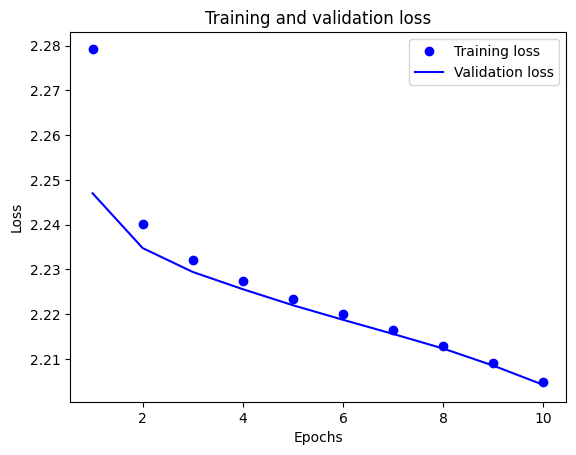

In [103]:
plot_loss(train_loss_all, val_loss_all)

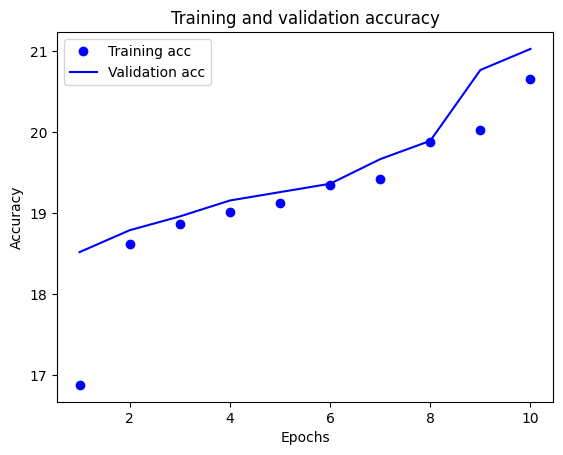

In [104]:
plot_accuracy(train_acc_all, val_acc_all)

Exercitiul 2

In [105]:
!pip -q install torchsummary

from torchsummary import summary
import torch

device = try_gpu()
net = net.to(device)
summary(net, (3, 224, 224), device=device.type)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 224, 224]             896
       BatchNorm2d-2         [-1, 32, 224, 224]              64
              ReLU-3         [-1, 32, 224, 224]               0
            Conv2d-4         [-1, 32, 224, 224]             320
            Conv2d-5         [-1, 64, 224, 224]           2,112
       BatchNorm2d-6         [-1, 64, 224, 224]             128
              ReLU-7         [-1, 64, 224, 224]               0
DepthwiseSeparableConvBlock-8         [-1, 64, 224, 224]               0
            Conv2d-9         [-1, 64, 224, 224]             640
           Conv2d-10        [-1, 128, 224, 224]           8,320
      BatchNorm2d-11        [-1, 128, 224, 224]             256
             ReLU-12        [-1, 128, 224, 224]               0
DepthwiseSeparableConvBlock-13        [-1, 128, 224, 224]               0
           Conv2d-14

Exercitiul 3

In [106]:
import torch
from torch import nn
from torch.nn import functional as F
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt

torch.manual_seed(42)
torch.backends.cudnn.deterministic = True

In [107]:
def load_data_svhn(batch_size, resize=None):
    """Download the Fashion-MNIST dataset and then load it into memory."""
    trans = [transforms.ToTensor()]
    if resize:
        trans.insert(0, transforms.Resize(resize))
    trans = transforms.Compose(trans)
    mnist_train = torchvision.datasets.SVHN(
        root="../data", split='train', transform=trans, download=True)
    mnist_test = torchvision.datasets.SVHN(
        root="../data", split='test', transform=trans, download=True)
    mnist_train, mnist_val = torch.utils.data.random_split(mnist_train, [43257, 30000],
                                                           generator=torch.Generator().manual_seed(42))
    return (torch.utils.data.DataLoader(mnist_train, batch_size, shuffle=True,
                            num_workers=2),
            torch.utils.data.DataLoader(mnist_val, batch_size, shuffle=False,
                            num_workers=2),
            torch.utils.data.DataLoader(mnist_test, batch_size, shuffle=False,
                            num_workers=2))

In [108]:
class BranchLeft(nn.Module):
  def __init__(self):
      super().__init__()
      self.c1 = nn.Conv2d(64,64,kernel_size=3,stride=2,padding=1)
      self.bn1 = nn.BatchNorm2d(64)
      self.relu1 = nn.ReLU()

      self.c2 = nn.Conv2d(64,128,kernel_size=3,stride=1,padding=0)
      self.bn2 = nn.BatchNorm2d(128)
      self.relu2 = nn.ReLU()

      self.c3 = nn.Conv2d(128,128,kernel_size=1,stride=1,padding=0)
      self.up = nn.Upsample(size=(16,16),mode="nearest")

  def forward(self,x):
      x = self.c1(x)
      x = self.bn1(x)
      x = self.relu1(x)

      x = self.c2(x)
      x = self.bn2(x)
      x = self.relu2(x)

      x = self.c3(x)
      x = self.up(x)

      return x

In [109]:
class BranchMid(nn.Module):
  def __init__(self):
      super().__init__()
      self.c1 = nn.Conv2d(64,32,kernel_size=1,stride=1,padding=0)
      self.bn1 = nn.BatchNorm2d(32)
      self.relu1 = nn.ReLU()

      self.c2 = nn.Conv2d(32,32,kernel_size=5,stride=1,padding=2)
      self.bn2 = nn.BatchNorm2d(32)
      self.relu2 = nn.ReLU()

      self.c3 = nn.Conv2d(32,128,kernel_size=3,stride=2,padding=1)
      self.relu3 = nn.ReLU()

  def forward(self,x):
      x = self.c1(x)
      x = self.bn1(x)
      x = self.relu1(x)

      x = self.c2(x)
      x = self.bn2(x)
      x = self.relu2(x)

      x = self.c3(x)
      x = self.relu3(x)

      return x

In [110]:
class BranchRight(nn.Module):
  def __init__(self):
      super().__init__()
      self.pool = nn.MaxPool2d(kernel_size=3,stride=1,padding=1)

      self.c1 = nn.Conv2d(64,128,kernel_size=1,stride=1,padding=0)
      self.bn1 = nn.BatchNorm2d(128)
      self.relu1 = nn.ReLU()

      self.c2 = nn.Conv2d(128,128,kernel_size=3,stride=2,padding=1)
      self.relu2 = nn.ReLU()

  def forward(self,x):
      x = self.pool(x)

      x = self.c1(x)
      x = self.bn1(x)
      x = self.relu1(x)

      x = self.c2(x)
      x = self.relu2(x)

      return x

In [111]:
class InceptionAddNet(nn.Module):
  def __init__(self):
      super().__init__()
      self.stem = nn.Sequential(
          nn.Conv2d(3,64,kernel_size=3,stride=1,padding=1),
          nn.BatchNorm2d(64),
          nn.ReLU()
      )

      self.branch_left = BranchLeft()
      self.branch_mid = BranchMid()
      self.branch_right = BranchRight()

      self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 10)
      )

  def forward(self,x):
      x = self.stem(x)
      y1 = self.branch_left(x)
      y2 = self.branch_mid(x)
      y3 = self.branch_right(x)
      y = y1 + y2 + y3
      return self.classifier(y)

In [112]:
def try_gpu(i=0):
    """Return gpu(i) if exists, otherwise return cpu()."""
    if torch.cuda.device_count() >= i + 1:
        return torch.device(f'cuda:{i}')
    return torch.device('cpu')

In [113]:
!pip -q install torchsummary
from torchsummary import summary

device = try_gpu()
net = InceptionAddNet().to(device)
summary(net, (3, 32, 32), device=device.type)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           1,792
       BatchNorm2d-2           [-1, 64, 32, 32]             128
              ReLU-3           [-1, 64, 32, 32]               0
            Conv2d-4           [-1, 64, 16, 16]          36,928
       BatchNorm2d-5           [-1, 64, 16, 16]             128
              ReLU-6           [-1, 64, 16, 16]               0
            Conv2d-7          [-1, 128, 14, 14]          73,856
       BatchNorm2d-8          [-1, 128, 14, 14]             256
              ReLU-9          [-1, 128, 14, 14]               0
           Conv2d-10          [-1, 128, 14, 14]          16,512
         Upsample-11          [-1, 128, 16, 16]               0
       BranchLeft-12          [-1, 128, 16, 16]               0
           Conv2d-13           [-1, 32, 32, 32]           2,080
      BatchNorm2d-14           [-1, 32,

In [114]:
def evaluate_accuracy(net, data_iter, loss, device):
    """Compute the accuracy for a model on a dataset."""
    net.eval()  # Set the model to evaluation mode

    total_loss = 0
    total_hits = 0
    total_samples = 0
    with torch.no_grad():
        for X, y in data_iter:
            X, y = X.to(device), y.to(device)
            y_hat = net(X)
            l = loss(y_hat, y)
            total_loss += float(l)
            total_hits += sum(net(X).argmax(axis=1).type(y.dtype) == y)
            total_samples += y.numel()
    return float(total_loss) / len(data_iter), float(total_hits) / total_samples  * 100

In [115]:
def train_epoch(net, train_iter, loss, optimizer, device):
    # Set the model to training mode
    net.train()
    # Sum of training loss, sum of training correct predictions, no. of examples
    total_loss = 0
    total_hits = 0
    total_samples = 0
    for X, y in train_iter:
        # Compute gradients and update parameters
        X, y = X.to(device), y.to(device)
        y_hat = net(X)
        l = loss(y_hat, y)
        # Using PyTorch built-in optimizer & loss criterion
        optimizer.zero_grad()
        l.backward()
        optimizer.step()
        total_loss += float(l)
        total_hits += sum(y_hat.argmax(axis=1).type(y.dtype) == y)
        total_samples += y.numel()
    # Return training loss and training accuracy
    return float(total_loss) / len(train_iter), float(total_hits) / total_samples  * 100

In [116]:
def train(net, train_iter, val_iter, test_iter, num_epochs, lr, device):
    """Train a model."""
    train_loss_all = []
    train_acc_all = []
    val_loss_all = []
    val_acc_all = []
    def init_weights(m):
        if type(m) == nn.Linear or type(m) == nn.Conv2d:
            nn.init.xavier_uniform_(m.weight)
    net.apply(init_weights)
    print('Training on', device)
    net.to(device)
    optimizer = torch.optim.Adam(net.parameters(), lr=lr)#aici---------------------------------
    loss = nn.CrossEntropyLoss()
    for epoch in range(num_epochs):
        train_loss, train_acc = train_epoch(net, train_iter, loss, optimizer, device)
        train_loss_all.append(train_loss)
        train_acc_all.append(train_acc)
        val_loss, val_acc = evaluate_accuracy(net, val_iter, loss, device)
        val_loss_all.append(val_loss)
        val_acc_all.append(val_acc)
        print(f'Epoch {epoch + 1}, Train loss {train_loss:.2f}, Train accuracy {train_acc:.2f}, Validation loss {val_loss:.2f}, Validation accuracy {val_acc:.2f}')
    test_loss, test_acc = evaluate_accuracy(net, test_iter, loss, device)
    print(f'Test loss {test_loss:.2f}, Test accuracy {test_acc:.2f}')

    return train_loss_all, train_acc_all, val_loss_all, val_acc_all

In [117]:
def plot_loss(train_loss_all, val_loss_all):
    epochs = range(1, len(train_loss_all) + 1)
    plt.plot(epochs, train_loss_all, 'bo', label='Training loss')
    plt.plot(epochs, val_loss_all, 'b', label='Validation loss')
    plt.title('Training and validation loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

In [118]:
def plot_accuracy(train_acc_all, val_acc_all):
    epochs = range(1, len(train_acc_all) + 1)
    plt.plot(epochs, train_acc_all, 'bo', label='Training acc')
    plt.plot(epochs, val_acc_all, 'b', label='Validation acc')
    plt.title('Training and validation accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

In [119]:
batch_size, lr, num_epochs = 128, 0.001, 10#aici-----------------------------------------------------
train_iter, val_iter, test_iter = load_data_svhn(batch_size)
train_loss_all, train_acc_all, val_loss_all, val_acc_all = train(net, train_iter, val_iter, test_iter, num_epochs, lr, try_gpu()) #2 min

Training on cuda:0
Epoch 1, Train loss 1.15, Train accuracy 70.09, Validation loss 0.64, Validation accuracy 81.07
Epoch 2, Train loss 0.50, Train accuracy 85.45, Validation loss 0.51, Validation accuracy 84.81
Epoch 3, Train loss 0.40, Train accuracy 88.15, Validation loss 0.48, Validation accuracy 86.25
Epoch 4, Train loss 0.35, Train accuracy 89.52, Validation loss 0.56, Validation accuracy 84.53
Epoch 5, Train loss 0.30, Train accuracy 90.92, Validation loss 0.56, Validation accuracy 85.05
Epoch 6, Train loss 0.27, Train accuracy 91.80, Validation loss 0.54, Validation accuracy 86.25
Epoch 7, Train loss 0.23, Train accuracy 92.67, Validation loss 0.59, Validation accuracy 85.53
Epoch 8, Train loss 0.21, Train accuracy 93.41, Validation loss 0.60, Validation accuracy 85.93
Epoch 9, Train loss 0.19, Train accuracy 94.01, Validation loss 0.65, Validation accuracy 84.85
Epoch 10, Train loss 0.16, Train accuracy 94.88, Validation loss 0.74, Validation accuracy 83.78
Test loss 0.90, Test

#**Laboratorul 10**

##Setul 1

Exercitiul 1

In [120]:
import hashlib
import os
import requests
import re
import collections
import random
import torch
from torch import nn
from torch.nn import functional as F
import math
import matplotlib.pyplot as plt
import zipfile

torch.manual_seed(42);

In [121]:
X_in = torch.rand((5,1,2))
X_h = torch.rand((1,1,4))

in_size = 2
in_hidden = 4

lay = nn.RNN(in_size, in_hidden)
lay(X_in,X_h)

(tensor([[[-0.0537,  0.1456,  0.7098, -0.2750]],
 
         [[ 0.1314,  0.5651,  0.5520, -0.4627]],
 
         [[ 0.3508,  0.5003,  0.3823, -0.4382]],
 
         [[ 0.3057,  0.4469,  0.4790, -0.4695]],
 
         [[ 0.4525,  0.6280,  0.3048, -0.5667]]], grad_fn=<StackBackward0>),
 tensor([[[ 0.4525,  0.6280,  0.3048, -0.5667]]], grad_fn=<StackBackward0>))

Exercitiul 2

In [122]:
import hashlib
import os
import requests
import re
import collections
import random
import torch
from torch import nn
from torch.nn import functional as F
import math
import matplotlib.pyplot as plt
import zipfile

torch.manual_seed(42);

In [123]:
def download(url, cache_dir=os.path.join('..', 'data')):
    """Download a file, return the local filename."""
    os.makedirs(cache_dir, exist_ok=True)
    fname = os.path.join(cache_dir, url.split('/')[-1])
    if os.path.exists(fname):
        with open(fname, 'rb') as f:
            while True:
                data = f.read(1048576)
                if not data:
                    break
        return fname
    print(f'Downloading {fname} from {url}...')
    r = requests.get(url, stream=True, verify=True)
    with open(fname, 'wb') as f:
        f.write(r.content)
    return fname

In [124]:
def read_time_machine():
    """Load the time machine dataset into a list of text lines."""
    with open(download('http://d2l-data.s3-accelerate.amazonaws.com/timemachine.txt'), 'r') as f:
        lines = f.readlines()
    return [re.sub('[^A-Za-z]+', ' ', line).strip().lower() for line in lines]

lines = read_time_machine()
print(f'# text lines: {len(lines)}')
print(lines[0])
print(lines[10])

# text lines: 3221
the time machine by h g wells
twinkled and his usually pale face was flushed and animated the


In [125]:
def tokenize(lines, token='word'):
    """Split text lines into word or character tokens."""
    if token == 'word':
        return [line.split() for line in lines]
    elif token == 'char':
        return [list(line) for line in lines]
    else:
        print('ERROR: unknown token type: ' + token)

tokens = tokenize(lines)
for i in range(11):
    print(tokens[i])

['the', 'time', 'machine', 'by', 'h', 'g', 'wells']
[]
[]
[]
[]
['i']
[]
[]
['the', 'time', 'traveller', 'for', 'so', 'it', 'will', 'be', 'convenient', 'to', 'speak', 'of', 'him']
['was', 'expounding', 'a', 'recondite', 'matter', 'to', 'us', 'his', 'grey', 'eyes', 'shone', 'and']
['twinkled', 'and', 'his', 'usually', 'pale', 'face', 'was', 'flushed', 'and', 'animated', 'the']


In [126]:
class Vocab:
    """Vocabulary for text."""
    def __init__(self, tokens=None, min_freq=0, reserved_tokens=None):
        if tokens is None:
            tokens = []
        if reserved_tokens is None:
            reserved_tokens = []
        # Sort according to frequencies
        counter = count_corpus(tokens)
        self._token_freqs = sorted(counter.items(), key=lambda x: x[1],
                                   reverse=True)
        # The index for the unknown token is 0
        self.idx_to_token = ['<unk>'] + reserved_tokens
        self.token_to_idx = {token: idx
                             for idx, token in enumerate(self.idx_to_token)}
        for token, freq in self._token_freqs:
            if freq < min_freq:
                break
            if token not in self.token_to_idx:
                self.idx_to_token.append(token)
                self.token_to_idx[token] = len(self.idx_to_token) - 1

    def __len__(self):
        return len(self.idx_to_token)

    def __getitem__(self, tokens):
        if not isinstance(tokens, (list, tuple)):
            return self.token_to_idx.get(tokens, self.unk)
        return [self.__getitem__(token) for token in tokens]

    def to_tokens(self, indices):
        if not isinstance(indices, (list, tuple)):
            return self.idx_to_token[indices]
        return [self.idx_to_token[index] for index in indices]

    @property
    def unk(self):  # Index for the unknown token
        return 0

    @property
    def token_freqs(self):  # Token frequencies
        return self._token_freqs

def count_corpus(tokens):
    """Count token frequencies."""
    # Here `tokens` is a 1D list or 2D list
    if len(tokens) == 0 or isinstance(tokens[0], list):
        # Flatten a list of token lists into a list of tokens
        tokens = [token for line in tokens for token in line]
    return collections.Counter(tokens)

In [127]:
def load_corpus_time_machine(max_tokens=-1):
    """Return token indices and the vocabulary of the time machine dataset."""
    lines = read_time_machine()
    tokens = tokenize(lines, 'char')
    vocab = Vocab(tokens)
    # Since each text line in the time machine dataset is not necessarily a
    # sentence or a paragraph, flatten all the text lines into a single list
    corpus = [vocab[token] for line in tokens for token in line]
    if max_tokens > 0:
        corpus = corpus[:max_tokens]
    return corpus, vocab

corpus, vocab = load_corpus_time_machine()
len(corpus), len(vocab)

(170580, 28)

In [128]:
def seq_data_iter_sequential(corpus, batch_size, num_steps):
    """Generate a mini-batch of subsequences using sequential partitioning."""
    # Start with a random offset to partition a sequence
    offset = random.randint(0, num_steps)
    num_tokens = ((len(corpus) - offset - 1) // batch_size) * batch_size
    Xs = torch.tensor(corpus[offset: offset + num_tokens])
    Ys = torch.tensor(corpus[offset + 1: offset + 1 + num_tokens])
    Xs, Ys = Xs.reshape(batch_size, -1), Ys.reshape(batch_size, -1)
    num_batches = Xs.shape[1] // num_steps
    for i in range(0, num_steps * num_batches, num_steps):
        X = Xs[:, i: i + num_steps]
        Y = Ys[:, i: i + num_steps]
        yield X, Y

In [129]:
class SeqDataLoader:
    """An iterator to load sequence data."""
    def __init__(self, batch_size, num_steps, max_tokens):
        self.corpus, self.vocab = load_corpus_time_machine(max_tokens)
        self.batch_size, self.num_steps = batch_size, num_steps

    def __iter__(self):
        return seq_data_iter_sequential(self.corpus, self.batch_size, self.num_steps)

In [130]:
def load_data_time_machine(batch_size, num_steps, max_tokens=10000):
    """Return the iterator and the vocabulary of the time machine dataset."""
    data_iter = SeqDataLoader(
        batch_size, num_steps, max_tokens)
    return data_iter, data_iter.vocab

In [131]:
batch_size, num_steps = 30, 10 #aici----------------------------------------------------------------------------
train_iter, vocab = load_data_time_machine(batch_size, num_steps)

In [132]:
num_hiddens = 32#aici--------------------------------------
rnn_layer = nn.RNN(len(vocab), num_hiddens,num_layers=2)#aici------------------------------------

In [133]:
class RNNModel(nn.Module):
    """The RNN model."""
    def __init__(self, rnn_layer, vocab_size, **kwargs):
        super(RNNModel, self).__init__(**kwargs)
        self.rnn = rnn_layer
        self.vocab_size = vocab_size
        self.num_hiddens = self.rnn.hidden_size
        self.linear = nn.Linear(self.num_hiddens, self.vocab_size)

    def forward(self, inputs, state):
        X = F.one_hot(inputs.T.long(), self.vocab_size)
        X = X.to(torch.float32)
        Y, state = self.rnn(X, state)
        # The fully connected layer will first change the shape of `Y` to
        # (`num_steps` * `batch_size`, `num_hiddens`). Its output shape is
        # (`num_steps` * `batch_size`, `vocab_size`).
        output = self.linear(Y.reshape((-1, Y.shape[-1])))
        return output, state

    def begin_state(self, device, batch_size=1):
        if not isinstance(self.rnn, nn.LSTM):
            # `nn.GRU` takes a tensor as hidden state
            return  torch.zeros((self.rnn.num_layers,
                                 batch_size, self.num_hiddens),
                                 device=device)
        else:
            # `nn.LSTM` takes a tuple of hidden states
            return (torch.zeros((
                self.rnn.num_layers,
                batch_size, self.num_hiddens), device=device),
                    torch.zeros((
                        self.rnn.num_layers,
                        batch_size, self.num_hiddens), device=device))

In [134]:
def predict(prefix, num_preds, net, vocab, device):
    """Generate new characters following the `prefix`."""
    state = net.begin_state(batch_size=1, device=device)
    outputs = [vocab[prefix[0]]]
    get_input = lambda: torch.tensor([outputs[-1]], device=device).reshape((1, 1))
    for y in prefix[1:]:  # Warm-up period
        _, state = net(get_input(), state)
        outputs.append(vocab[y])
    for _ in range(num_preds):  # Predict `num_preds` steps
        y, state = net(get_input(), state)
        outputs.append(int(y.argmax(dim=1).reshape(1)))
    return ''.join([vocab.idx_to_token[i] for i in outputs])

In [135]:
def try_gpu(i=0):
    """Return gpu(i) if exists, otherwise return cpu()."""
    if torch.cuda.device_count() >= i + 1:
        return torch.device(f'cuda:{i}')
    return torch.device('cpu')

In [136]:
device = try_gpu()
net = RNNModel(rnn_layer, vocab_size=len(vocab))
net = net.to(device)
predict('traveller', 10, net, vocab, device)

'travellerggxxxxxxxx'

In [137]:
def grad_clipping(net, theta):
    """Clip the gradient."""
    params = [p for p in net.parameters() if p.requires_grad]
    norm = torch.sqrt(sum(torch.sum((p.grad ** 2)) for p in params))
    if norm > theta:
        for param in params:
            param.grad[:] *= theta / norm

In [138]:
def train_epoch(net, train_iter, loss, optimizer, device):
    """Train a net within one epoch."""
    state = None
    # Sum of training loss, no. of tokens
    total_loss = 0
    total_tokens = 0
    for X, Y in train_iter:
        if state is None:
            # Initialize `state` when it is the first iteration
            state = net.begin_state(batch_size=X.shape[0], device=device)
        else:
            if not isinstance(state, tuple):
                # `state` is a tensor for `nn.GRU`
                state.detach_()
            else:
                # `state` is a tuple of tensors for `nn.LSTM`
                for s in state:
                    s.detach_()
        y = Y.T.reshape(-1)
        X, y = X.to(device), y.to(device)
        y_hat, state = net(X, state)
        l = loss(y_hat, y.long()).mean()
        optimizer.zero_grad()
        l.backward()
        grad_clipping(net, 1)
        optimizer.step()
        total_loss += float(l * y.numel())
        total_tokens += y.numel()
    return math.exp(total_loss / total_tokens)

In [139]:
def train(net, train_iter, vocab, lr, num_epochs, device):
    """Train a model."""
    loss = nn.CrossEntropyLoss()
    perplexities = []
    # Initialize
    optimizer = torch.optim.SGD(net.parameters(), lr)
    # Train and predict
    for epoch in range(num_epochs):
        ppl = train_epoch(
            net, train_iter, loss, optimizer, device)
        if (epoch + 1) % 10 == 0:
            print(predict('traveller', 20, net, vocab, device))#aici--------------------------------------
            perplexities.append(ppl)
    print(f'perplexity {ppl:.1f}, device {str(device)}')
    print(predict('traveller', 20, net, vocab, device))#aici----------------------------------------------

    return perplexities

In [140]:
num_epochs, lr = 200, 1.5#aici---------------------------------------------------------
perplexities = train(net, train_iter, vocab, lr, num_epochs, device) #1 min

traveller the the the the the
traveller the the the the the
traveller so have the the the
traveller the the the the the
traveller a space and and and
travellertholog on the the th
traveller and and and and and
traveller and and and and and
traveller dimension the momen
traveller the time the time t
traveller and and and and and
traveller dimension the time 
traveller and and and and and
traveller the time traveller 
traveller and the time travel
traveller a mat the for a mat
traveller the time traveller 
traveller and a man a co dee 
traveller and and and and and
traveller and a moment a mome
perplexity 5.0, device cuda:0
traveller and a moment a mome


In [141]:
def plot_perplexity(perplexities):
    epochs = range(10, len(perplexities * 10) + 1, 10)
    plt.plot(epochs, perplexities, 'b', label='Train perplexity')
    plt.title('Training perplexity')
    plt.xlabel('Epochs')
    plt.ylabel('Perplexity')
    plt.legend()
    plt.show()

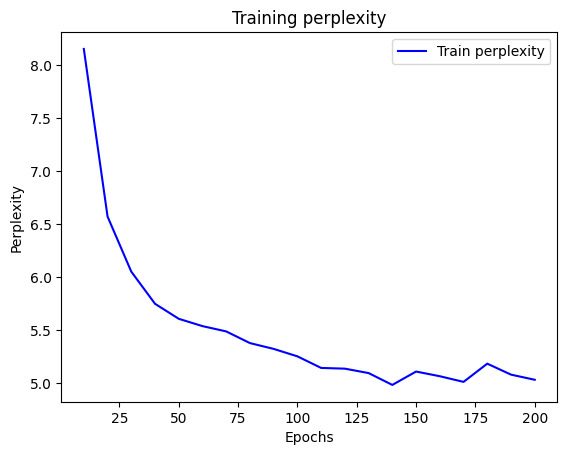

In [142]:
plot_perplexity(perplexities)

Exercitiul 3

In [143]:
import hashlib
import os
import requests
import re
import collections
import random
import torch
from torch import nn
from torch.nn import functional as F
import math
import matplotlib.pyplot as plt
import zipfile

torch.manual_seed(42);

In [144]:
def download(url, cache_dir=os.path.join('..', 'data')):
    """Download a file, return the local filename."""
    os.makedirs(cache_dir, exist_ok=True)
    fname = os.path.join(cache_dir, url.split('/')[-1])
    if os.path.exists(fname):
        with open(fname, 'rb') as f:
            while True:
                data = f.read(1048576)
                if not data:
                    break
        return fname
    print(f'Downloading {fname} from {url}...')
    r = requests.get(url, stream=True, verify=True)
    with open(fname, 'wb') as f:
        f.write(r.content)
    return fname

In [145]:
def read_time_machine():
    """Load the time machine dataset into a list of text lines."""
    with open(download('http://d2l-data.s3-accelerate.amazonaws.com/timemachine.txt'), 'r') as f:
        lines = f.readlines()
    return [re.sub('[^A-Za-z]+', ' ', line).strip().lower() for line in lines]

lines = read_time_machine()
print(f'# text lines: {len(lines)}')
print(lines[0])
print(lines[10])

# text lines: 3221
the time machine by h g wells
twinkled and his usually pale face was flushed and animated the


In [146]:
def tokenize(lines, token='word'):
    """Split text lines into word or character tokens."""
    if token == 'word':
        return [line.split() for line in lines]
    elif token == 'char':
        return [list(line) for line in lines]
    else:
        print('ERROR: unknown token type: ' + token)

tokens = tokenize(lines)
for i in range(11):
    print(tokens[i])

['the', 'time', 'machine', 'by', 'h', 'g', 'wells']
[]
[]
[]
[]
['i']
[]
[]
['the', 'time', 'traveller', 'for', 'so', 'it', 'will', 'be', 'convenient', 'to', 'speak', 'of', 'him']
['was', 'expounding', 'a', 'recondite', 'matter', 'to', 'us', 'his', 'grey', 'eyes', 'shone', 'and']
['twinkled', 'and', 'his', 'usually', 'pale', 'face', 'was', 'flushed', 'and', 'animated', 'the']


In [147]:
class Vocab:
    """Vocabulary for text."""
    def __init__(self, tokens=None, min_freq=0, reserved_tokens=None):
        if tokens is None:
            tokens = []
        if reserved_tokens is None:
            reserved_tokens = []
        # Sort according to frequencies
        counter = count_corpus(tokens)
        self._token_freqs = sorted(counter.items(), key=lambda x: x[1],
                                   reverse=True)
        # The index for the unknown token is 0
        self.idx_to_token = ['<unk>'] + reserved_tokens
        self.token_to_idx = {token: idx
                             for idx, token in enumerate(self.idx_to_token)}
        for token, freq in self._token_freqs:
            if freq < min_freq:
                break
            if token not in self.token_to_idx:
                self.idx_to_token.append(token)
                self.token_to_idx[token] = len(self.idx_to_token) - 1

    def __len__(self):
        return len(self.idx_to_token)

    def __getitem__(self, tokens):
        if not isinstance(tokens, (list, tuple)):
            return self.token_to_idx.get(tokens, self.unk)
        return [self.__getitem__(token) for token in tokens]

    def to_tokens(self, indices):
        if not isinstance(indices, (list, tuple)):
            return self.idx_to_token[indices]
        return [self.idx_to_token[index] for index in indices]

    @property
    def unk(self):  # Index for the unknown token
        return 0

    @property
    def token_freqs(self):  # Token frequencies
        return self._token_freqs

def count_corpus(tokens):
    """Count token frequencies."""
    # Here `tokens` is a 1D list or 2D list
    if len(tokens) == 0 or isinstance(tokens[0], list):
        # Flatten a list of token lists into a list of tokens
        tokens = [token for line in tokens for token in line]
    return collections.Counter(tokens)

In [148]:
def load_corpus_time_machine(max_tokens=-1):
    """Return token indices and the vocabulary of the time machine dataset."""
    lines = read_time_machine()
    tokens = tokenize(lines, 'char')
    vocab = Vocab(tokens)
    # Since each text line in the time machine dataset is not necessarily a
    # sentence or a paragraph, flatten all the text lines into a single list
    corpus = [vocab[token] for line in tokens for token in line]
    if max_tokens > 0:
        corpus = corpus[:max_tokens]
    return corpus, vocab

corpus, vocab = load_corpus_time_machine()
len(corpus), len(vocab)

(170580, 28)

In [149]:
def seq_data_iter_sequential(corpus, batch_size, num_steps):
    """Generate a mini-batch of subsequences using sequential partitioning."""
    # Start with a random offset to partition a sequence
    offset = random.randint(0, num_steps)
    num_tokens = ((len(corpus) - offset - 1) // batch_size) * batch_size
    Xs = torch.tensor(corpus[offset: offset + num_tokens])
    Ys = torch.tensor(corpus[offset + 1: offset + 1 + num_tokens])
    Xs, Ys = Xs.reshape(batch_size, -1), Ys.reshape(batch_size, -1)
    num_batches = Xs.shape[1] // num_steps
    for i in range(0, num_steps * num_batches, num_steps):
        X = Xs[:, i: i + num_steps]
        Y = Ys[:, i: i + num_steps]
        yield X, Y

In [150]:
class SeqDataLoader:
    """An iterator to load sequence data."""
    def __init__(self, batch_size, num_steps, max_tokens):
        self.corpus, self.vocab = load_corpus_time_machine(max_tokens)
        self.batch_size, self.num_steps = batch_size, num_steps

    def __iter__(self):
        return seq_data_iter_sequential(self.corpus, self.batch_size, self.num_steps)

In [151]:
def load_data_time_machine(batch_size, num_steps, max_tokens=10000):
    """Return the iterator and the vocabulary of the time machine dataset."""
    data_iter = SeqDataLoader(
        batch_size, num_steps, max_tokens)
    return data_iter, data_iter.vocab

In [152]:
batch_size, num_steps = 25, 10#aici---------
train_iter, vocab = load_data_time_machine(batch_size, num_steps)

In [153]:
class RNNModel(nn.Module):
    """The RNN model."""
    def __init__(self, rnn_layer, vocab_size, **kwargs):
        super(RNNModel, self).__init__(**kwargs)
        self.rnn = rnn_layer
        self.vocab_size = vocab_size
        self.num_hiddens = self.rnn.hidden_size
        self.linear = nn.Linear(self.num_hiddens, self.vocab_size)

    def forward(self, inputs, state):
        X = F.one_hot(inputs.T.long(), self.vocab_size)
        X = X.to(torch.float32)
        Y, state = self.rnn(X, state)
        # The fully connected layer will first change the shape of `Y` to
        # (`num_steps` * `batch_size`, `num_hiddens`). Its output shape is
        # (`num_steps` * `batch_size`, `vocab_size`).
        output = self.linear(Y.reshape((-1, Y.shape[-1])))
        return output, state

    def begin_state(self, device, batch_size=1):
        if not isinstance(self.rnn, nn.LSTM):
            # `nn.GRU` takes a tensor as hidden state
            return  torch.zeros((self.rnn.num_layers,
                                 batch_size, self.num_hiddens),
                                 device=device)
        else:
            # `nn.LSTM` takes a tuple of hidden states
            return (torch.zeros((
                self.rnn.num_layers,
                batch_size, self.num_hiddens), device=device),
                    torch.zeros((
                        self.rnn.num_layers,
                        batch_size, self.num_hiddens), device=device))

In [154]:
def predict(prefix, num_preds, net, vocab, device):
    """Generate new characters following the `prefix`."""
    state = net.begin_state(batch_size=1, device=device)
    outputs = [vocab[prefix[0]]]
    get_input = lambda: torch.tensor([outputs[-1]], device=device).reshape((1, 1))
    for y in prefix[1:]:  # Warm-up period
        _, state = net(get_input(), state)
        outputs.append(vocab[y])
    for _ in range(num_preds):  # Predict `num_preds` steps
        y, state = net(get_input(), state)
        outputs.append(int(y.argmax(dim=1).reshape(1)))
    return ''.join([vocab.idx_to_token[i] for i in outputs])

In [155]:
def try_gpu(i=0):
    """Return gpu(i) if exists, otherwise return cpu()."""
    if torch.cuda.device_count() >= i + 1:
        return torch.device(f'cuda:{i}')
    return torch.device('cpu')

In [156]:
device = try_gpu()
net = RNNModel(rnn_layer, vocab_size=len(vocab))
net = net.to(device)
predict('time', 10, net, vocab, device)

'timewlawpafpaf'

In [157]:
def grad_clipping(net, theta):
    """Clip the gradient."""
    params = [p for p in net.parameters() if p.requires_grad]
    norm = torch.sqrt(sum(torch.sum((p.grad ** 2)) for p in params))
    if norm > theta:
        for param in params:
            param.grad[:] *= theta / norm

In [158]:
def train_epoch(net, train_iter, loss, optimizer, device):
    """Train a net within one epoch."""
    state = None
    # Sum of training loss, no. of tokens
    total_loss = 0
    total_tokens = 0
    for X, Y in train_iter:
        if state is None:
            # Initialize `state` when it is the first iteration
            state = net.begin_state(batch_size=X.shape[0], device=device)
        else:
            if not isinstance(state, tuple):
                # `state` is a tensor for `nn.GRU`
                state.detach_()
            else:
                # `state` is a tuple of tensors for `nn.LSTM`
                for s in state:
                    s.detach_()
        y = Y.T.reshape(-1)
        X, y = X.to(device), y.to(device)
        y_hat, state = net(X, state)
        l = loss(y_hat, y.long()).mean()
        optimizer.zero_grad()
        l.backward()
        grad_clipping(net, 1)
        optimizer.step()
        total_loss += float(l * y.numel())
        total_tokens += y.numel()
    return math.exp(total_loss / total_tokens)

In [159]:
def train(net, train_iter, vocab, lr, num_epochs, device):
    """Train a model."""
    loss = nn.CrossEntropyLoss()
    perplexities = []
    # Initialize
    optimizer = torch.optim.SGD(net.parameters(), lr)
    # Train and predict
    for epoch in range(num_epochs):
        ppl = train_epoch(
            net, train_iter, loss, optimizer, device)
        if (epoch + 1) % 10 == 0:
            print(predict('time', 60, net, vocab, device))
            perplexities.append(ppl)
    print(f'perplexity {ppl:.1f}, device {str(device)}')
    print(predict('time', 60, net, vocab, device))

    return perplexities

In [160]:
vocab_size, num_hiddens, device = len(vocab), 256, try_gpu()
num_epochs, lr = 400, 2.5#aici----------------------------------------------------------

num_inputs = vocab_size
gru_layer = nn.LSTM(num_inputs, num_hiddens, num_layers=2)#aici--------------------------
model = RNNModel(gru_layer, len(vocab))
model = model.to(device)
perplexities = train(model, train_iter, vocab, lr, num_epochs, device) #4 min

time the the the the the the the the the the the the the the the
time the the the the the the the the the the the the the the the
time traveller the time traveller the time traveller the time tr
time traveller this haisharine i hist hare direasion along the t
time so herlook this fourth dimensions of space but you are way 
time there isno difference between time and any of the three dim
time machine by h g wellsithe time traveller came back andfilby 
time brightening in a quite transitory mannerwell i do not mind 
time brightening in a quite transitory mannerwell i do not mind 
time brightening in a quite transitory mannerwell i do not mind 
time brightening in a quite transitory mannerwell i do not mind 
time machine by h g wellsithe time traveller came back andfilby 
time brightening in a quite transitory mannerwell i do not mind 
time brightening in a quite transitory mannerwell i do not mind 
time brightening in a quite transitory mannerwell i do not mind 
time brightening in a qui

In [161]:
def plot_perplexity(perplexities):
    epochs = range(10, len(perplexities * 10) + 1, 10)
    plt.plot(epochs, perplexities, 'b', label='Train perplexity')
    plt.title('Training perplexity')
    plt.xlabel('Epochs')
    plt.ylabel('Perplexity')
    plt.legend()
    plt.show()

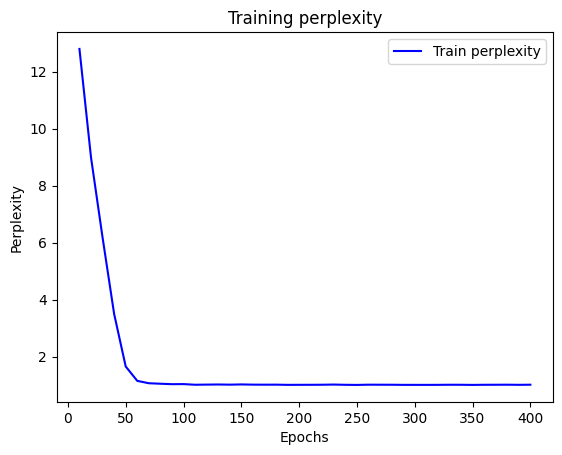

In [162]:
plot_perplexity(perplexities)

##Setul 2

Exercitiul 1

In [163]:
import hashlib
import os
import requests
import re
import collections
import random
import torch
from torch import nn
from torch.nn import functional as F
import math
import matplotlib.pyplot as plt
import zipfile

torch.manual_seed(42);

In [164]:
def download(url, cache_dir=os.path.join('..', 'data')):
    """Download a file, return the local filename."""
    os.makedirs(cache_dir, exist_ok=True)
    fname = os.path.join(cache_dir, url.split('/')[-1])
    if os.path.exists(fname):
        with open(fname, 'rb') as f:
            while True:
                data = f.read(1048576)
                if not data:
                    break
        return fname
    print(f'Downloading {fname} from {url}...')
    r = requests.get(url, stream=True, verify=True)
    with open(fname, 'wb') as f:
        f.write(r.content)
    return fname

In [165]:
def read_time_machine():
    """Load the time machine dataset into a list of text lines."""
    with open(download('https://www.gutenberg.org/files/84/84-0.txt'), 'r') as f:#aici-------------------------
        lines = f.readlines()
    return [re.sub('[^A-Za-z]+', ' ', line).strip().lower() for line in lines]

lines = read_time_machine()
print(f'# text lines: {len(lines)}')
print(lines[0])
print(lines[10])

# text lines: 7362
start of the project gutenberg ebook



In [166]:
def tokenize(lines, token='word'):
    """Split text lines into word or character tokens."""
    if token == 'word':
        return [line.split() for line in lines]
    elif token == 'char':
        return [list(line) for line in lines]
    else:
        print('ERROR: unknown token type: ' + token)

tokens = tokenize(lines)
for i in range(11):
    print(tokens[i])

['start', 'of', 'the', 'project', 'gutenberg', 'ebook']
[]
['frankenstein']
[]
['or', 'the', 'modern', 'prometheus']
[]
['by', 'mary', 'wollstonecraft', 'godwin', 'shelley']
[]
[]
['contents']
[]


In [167]:
class Vocab:
    """Vocabulary for text."""
    def __init__(self, tokens=None, min_freq=0, reserved_tokens=None):
        if tokens is None:
            tokens = []
        if reserved_tokens is None:
            reserved_tokens = []
        # Sort according to frequencies
        counter = count_corpus(tokens)
        self._token_freqs = sorted(counter.items(), key=lambda x: x[1],
                                   reverse=True)
        # The index for the unknown token is 0
        self.idx_to_token = ['<unk>'] + reserved_tokens
        self.token_to_idx = {token: idx
                             for idx, token in enumerate(self.idx_to_token)}
        for token, freq in self._token_freqs:
            if freq < min_freq:
                break
            if token not in self.token_to_idx:
                self.idx_to_token.append(token)
                self.token_to_idx[token] = len(self.idx_to_token) - 1

    def __len__(self):
        return len(self.idx_to_token)

    def __getitem__(self, tokens):
        if not isinstance(tokens, (list, tuple)):
            return self.token_to_idx.get(tokens, self.unk)
        return [self.__getitem__(token) for token in tokens]

    def to_tokens(self, indices):
        if not isinstance(indices, (list, tuple)):
            return self.idx_to_token[indices]
        return [self.idx_to_token[index] for index in indices]

    @property
    def unk(self):  # Index for the unknown token
        return 0

    @property
    def token_freqs(self):  # Token frequencies
        return self._token_freqs

def count_corpus(tokens):
    """Count token frequencies."""
    # Here `tokens` is a 1D list or 2D list
    if len(tokens) == 0 or isinstance(tokens[0], list):
        # Flatten a list of token lists into a list of tokens
        tokens = [token for line in tokens for token in line]
    return collections.Counter(tokens)

In [168]:
def load_corpus_time_machine(max_tokens=-1):
    """Return token indices and the vocabulary of the time machine dataset."""
    lines = read_time_machine()
    tokens = tokenize(lines, 'char')
    vocab = Vocab(tokens)
    # Since each text line in the time machine dataset is not necessarily a
    # sentence or a paragraph, flatten all the text lines into a single list
    corpus = [vocab[token] for line in tokens for token in line]
    if max_tokens > 0:
        corpus = corpus[:max_tokens]
    return corpus, vocab

corpus, vocab = load_corpus_time_machine()
len(corpus), len(vocab)

(401371, 28)

In [169]:
def seq_data_iter_sequential(corpus, batch_size, num_steps):
    """Generate a mini-batch of subsequences using sequential partitioning."""
    # Start with a random offset to partition a sequence
    offset = random.randint(0, num_steps)
    num_tokens = ((len(corpus) - offset - 1) // batch_size) * batch_size
    Xs = torch.tensor(corpus[offset: offset + num_tokens])
    Ys = torch.tensor(corpus[offset + 1: offset + 1 + num_tokens])
    Xs, Ys = Xs.reshape(batch_size, -1), Ys.reshape(batch_size, -1)
    num_batches = Xs.shape[1] // num_steps
    for i in range(0, num_steps * num_batches, num_steps):
        X = Xs[:, i: i + num_steps]
        Y = Ys[:, i: i + num_steps]
        yield X, Y

In [170]:
class SeqDataLoader:
    """An iterator to load sequence data."""
    def __init__(self, batch_size, num_steps, max_tokens):
        self.corpus, self.vocab = load_corpus_time_machine(max_tokens)
        self.batch_size, self.num_steps = batch_size, num_steps

    def __iter__(self):
        return seq_data_iter_sequential(self.corpus, self.batch_size, self.num_steps)

In [171]:
def load_data_time_machine(batch_size, num_steps, max_tokens=10000):
    """Return the iterator and the vocabulary of the time machine dataset."""
    data_iter = SeqDataLoader(
        batch_size, num_steps, max_tokens)
    return data_iter, data_iter.vocab

In [172]:
batch_size, num_steps = 32, 50
train_iter, vocab = load_data_time_machine(batch_size, num_steps, max_tokens=100000)

In [173]:
num_hiddens = 128
#rnn_layer = nn.LSTM(len(vocab), num_hiddens,num_layers=2)

In [174]:
class RNNModel(nn.Module):
    """The RNN model."""
    def __init__(self, rnn_layer, vocab_size, **kwargs):
        super(RNNModel, self).__init__(**kwargs)
        self.rnn = rnn_layer
        self.vocab_size = vocab_size
        self.num_hiddens = self.rnn.hidden_size
        self.linear = nn.Linear(self.num_hiddens, self.vocab_size)

    def forward(self, inputs, state):
        X = F.one_hot(inputs.T.long(), self.vocab_size)
        X = X.to(torch.float32)
        Y, state = self.rnn(X, state)
        # The fully connected layer will first change the shape of `Y` to
        # (`num_steps` * `batch_size`, `num_hiddens`). Its output shape is
        # (`num_steps` * `batch_size`, `vocab_size`).
        output = self.linear(Y.reshape((-1, Y.shape[-1])))
        return output, state

    def begin_state(self, device, batch_size=1):
        if not isinstance(self.rnn, nn.LSTM):
            # `nn.GRU` takes a tensor as hidden state
            return  torch.zeros((self.rnn.num_layers,
                                 batch_size, self.num_hiddens),
                                 device=device)
        else:
            # `nn.LSTM` takes a tuple of hidden states
            return (torch.zeros((
                self.rnn.num_layers,
                batch_size, self.num_hiddens), device=device),
                    torch.zeros((
                        self.rnn.num_layers,
                        batch_size, self.num_hiddens), device=device))

In [175]:
def predict(prefix, num_preds, net, vocab, device):
    """Generate new characters following the `prefix`."""
    state = net.begin_state(batch_size=1, device=device)
    outputs = [vocab[prefix[0]]]
    get_input = lambda: torch.tensor([outputs[-1]], device=device).reshape((1, 1))
    for y in prefix[1:]:  # Warm-up period
        _, state = net(get_input(), state)
        outputs.append(vocab[y])
    for _ in range(num_preds):  # Predict `num_preds` steps
        y, state = net(get_input(), state)
        outputs.append(int(y.argmax(dim=1).reshape(1)))
    return ''.join([vocab.idx_to_token[i] for i in outputs])

In [176]:
def try_gpu(i=0):
    """Return gpu(i) if exists, otherwise return cpu()."""
    if torch.cuda.device_count() >= i + 1:
        return torch.device(f'cuda:{i}')
    return torch.device('cpu')

In [177]:
device = try_gpu()
net = RNNModel(rnn_layer, vocab_size=len(vocab))
net = net.to(device)
predict('the moster', 10, net, vocab, device)

'the mosterttfiiawgab'

In [178]:
def grad_clipping(net, theta):
    """Clip the gradient."""
    params = [p for p in net.parameters() if p.requires_grad]
    norm = torch.sqrt(sum(torch.sum((p.grad ** 2)) for p in params))
    if norm > theta:
        for param in params:
            param.grad[:] *= theta / norm

In [179]:
def train_epoch(net, train_iter, loss, optimizer, device):
    """Train a net within one epoch."""
    state = None
    # Sum of training loss, no. of tokens
    total_loss = 0
    total_tokens = 0
    for X, Y in train_iter:
        if state is None:
            # Initialize `state` when it is the first iteration
            state = net.begin_state(batch_size=X.shape[0], device=device)
        else:
            if not isinstance(state, tuple):
                # `state` is a tensor for `nn.GRU`
                state.detach_()
            else:
                # `state` is a tuple of tensors for `nn.LSTM`
                for s in state:
                    s.detach_()
        y = Y.T.reshape(-1)
        X, y = X.to(device), y.to(device)
        y_hat, state = net(X, state)
        l = loss(y_hat, y.long()).mean()
        optimizer.zero_grad()
        l.backward()
        grad_clipping(net, 1)
        optimizer.step()
        total_loss += float(l * y.numel())
        total_tokens += y.numel()
    return math.exp(total_loss / total_tokens)

In [180]:
def train(net, train_iter, vocab, lr, num_epochs, device):
    """Train a model."""
    loss = nn.CrossEntropyLoss()
    perplexities = []
    # Initialize
    optimizer = torch.optim.SGD(net.parameters(), lr)
    # Train and predict
    for epoch in range(num_epochs):
        ppl = train_epoch(
            net, train_iter, loss, optimizer, device)
        if (epoch + 1) % 10 == 0:
            print(predict('the monster', 100, net, vocab, device))
            perplexities.append(ppl)
    print(f'perplexity {ppl:.1f}, device {str(device)}')
    print(predict('the monster', 100, net, vocab, device))

    return perplexities

In [181]:
vocab_size, num_hiddens, device = len(vocab), 128, try_gpu() #aici-----------------
num_epochs, lr = 200, 1.2#aici-----------------------------------------------------

num_inputs = vocab_size
gru_layer = nn.LSTM(num_inputs, num_hiddens,num_layers=2)#aici---------------------
model = RNNModel(gru_layer, len(vocab))
model = model.to(device)
perplexities = train(model, train_iter, vocab, lr, num_epochs, device) #4 min

the monster ae te ae te ae te ae te ae te ae te ae te ae te ae te ae te ae te ae te ae te ae te ae te ae te ae 
the monstere the the the the the the the the the the the the the the the the the the the the the the the the th
the monster the sour the sour the sour the sour the sour the sour the sour the sour the sour the sour the sour 
the monster the sure and the sure and the sure and the sure and the sure and the sure and the sure and the sure
the monster the strange of the street of the strange of the street of the strange of the street of the strange 
the monster the stranger of the stranger of the stranger of the stranger of the stranger of the stranger of the
the monster the same of the same of the same of the same of the same of the same of the same of the same of the
the monster the same of the many of the most of the many of the most of the many of the most of the many of the
the monster discovered his feelings i was not been in the same of a consider the same of the same of a c

Exercitiul 3

In [182]:
import torch
import torch.nn as nn

torch.manual_seed(42)

class SentimentGRU(nn.Module):
    def __init__(self, vocab_size=10_000, embed_dim=64, hidden_size=128, num_classes=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.gru = nn.GRU(input_size=embed_dim, hidden_size=hidden_size, num_layers=1, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # x: (B, T) cu indici int
        emb = self.embedding(x)          # (B, T, 64)
        out, h = self.gru(emb)           # out: (B, T, 128), h: (1, B, 128)
        last = h[-1]                     # (B, 128)  -> sentiment = o singură etichetă pe secvență
        logits = self.fc(last)           # (B, 2)
        return logits, emb, out, h

# cerință: batch B=4, lungime T=20
B, T = 4, 20
x = torch.randint(low=0, high=10_000, size=(B, T), dtype=torch.long)

model = SentimentGRU(vocab_size=10_000, embed_dim=64, hidden_size=128, num_classes=2)

logits, emb, out, h = model(x)

print("Input:", x.shape)          # (4, 20)
print("Embedding:", emb.shape)    # (4, 20, 64)
print("GRU out:", out.shape)      # (4, 20, 128)
print("GRU h:", h.shape)          # (1, 4, 128)
print("Logits:", logits.shape)    # (4, 2)  <- output-ul final pentru clasificare

# (b) nr. parametri trainabili
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Total trainable params:", total_params)


Input: torch.Size([4, 20])
Embedding: torch.Size([4, 20, 64])
GRU out: torch.Size([4, 20, 128])
GRU h: torch.Size([1, 4, 128])
Logits: torch.Size([4, 2])
Total trainable params: 714754


#**Laboratorul 11**

Exercitiul 1

In [352]:
import torch
from torch import nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import math
import os
import requests
import zipfile
import collections

torch.manual_seed(42);

In [353]:
def show_heatmaps(matrices, xlabel, ylabel, titles=None, figsize=(2.5, 2.5),
                  cmap='Reds'):
    """Show heatmaps of matrices."""
    num_rows, num_cols = matrices.shape[0], matrices.shape[1]
    fig, axes = plt.subplots(num_rows, num_cols, figsize=figsize,
                             sharex=True, sharey=True, squeeze=False)
    for i, (row_axes, row_matrices) in enumerate(zip(axes, matrices)):
        for j, (ax, matrix) in enumerate(zip(row_axes, row_matrices)):
            pcm = ax.imshow(matrix.detach().numpy(), cmap=cmap)
            if i == num_rows - 1:
                ax.set_xlabel(xlabel)
            if j == 0:
                ax.set_ylabel(ylabel)
            if titles:
                ax.set_title(titles[j])
    fig.colorbar(pcm, ax=axes, shrink=0.6);

In [354]:
n_train = 100  #aici---------------------------------------------------------------------
x_train, _ = torch.sort(torch.rand(n_train) * 10)   # Training inputs--------------------

In [355]:
def f(x):
    return -4 * torch.cos(x) + 3*x#aici--------------------------------

y_train = f(x_train) + torch.normal(0.0, 0.08, (n_train,))  #aici ii 0.0 means ul si 0.08 standard division---------------
x_test = torch.arange(0, 10, 0.1)  # Testing examples si aici--------------------------------------------------------------
y_truth = f(x_test)  # Ground-truth outputs for the testing examples
n_test = len(x_test)  # No. of testing examples
n_test

100

In [356]:
def plot_kernel_reg(y_hat):
    plt.plot(x_test, y_truth, label='Truth')
    plt.plot(x_test, y_hat, label='Pred')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.xlim([0,10])
    plt.ylim([-5,25])
    plt.legend()
    plt.plot(x_train, y_train, 'o', alpha=0.5);

In [357]:
class NWKernelRegression(nn.Module):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.w = nn.Parameter(torch.rand((1,), requires_grad=True))

    def forward(self, queries, keys, values):
        # Shape of the output `queries` and `attention_weights` is:
        # (no. of queries, no. of key-value pairs)
        queries = queries.repeat_interleave(keys.shape[1]).reshape((-1, keys.shape[1]))
        self.attention_weights = F.softmax(-((queries - keys) * self.w)**2 / 2, dim=1)
        # Shape of `values` is: (no. of queries, no. of key-value pairs)
        return torch.bmm(self.attention_weights.unsqueeze(1),
                         values.unsqueeze(-1)).reshape(-1)

In [358]:
# Shape of `X_tile` is: (`n_train`, `n_train`), where each column contains the
# same training inputs
X_tile = x_train.repeat((n_train, 1))
# Shape of `Y_tile` is: (`n_train`, `n_train`), where each column contains the
# same training outputs
Y_tile = y_train.repeat((n_train, 1))
# Shape of `keys` is: ('n_train', 'n_train' - 1)
keys = X_tile[(1 - torch.eye(n_train)).type(torch.bool)].reshape((n_train, -1))
# Shape of `values` is: ('n_train', 'n_train' - 1)
values = Y_tile[(1 - torch.eye(n_train)).type(torch.bool)].reshape((n_train, -1))

In [359]:
def plot_loss_regression(train_loss_all):
    epochs = range(1, len(train_loss_all) + 1)
    plt.plot(epochs, train_loss_all, 'b', label='Train loss')
    plt.title('Training loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

epoch 1, loss 1346.542480
epoch 2, loss 8.744869
epoch 3, loss 8.744869
epoch 4, loss 8.744869
epoch 5, loss 8.744869


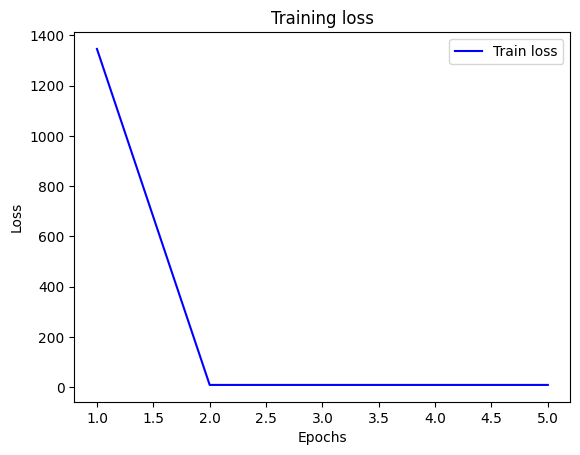

In [360]:
net = NWKernelRegression()
loss = nn.MSELoss(reduction='none')
optimizer = torch.optim.SGD(net.parameters(), lr=0.5)

train_loss_all = []
for epoch in range(5):
    optimizer.zero_grad()
    l = loss(net(x_train, keys, values), y_train)
    l.sum().backward()
    optimizer.step()
    print(f'epoch {epoch + 1}, loss {float(l.sum()):.6f}')
    train_loss_all.append(float(l.sum()))

plot_loss_regression(train_loss_all)

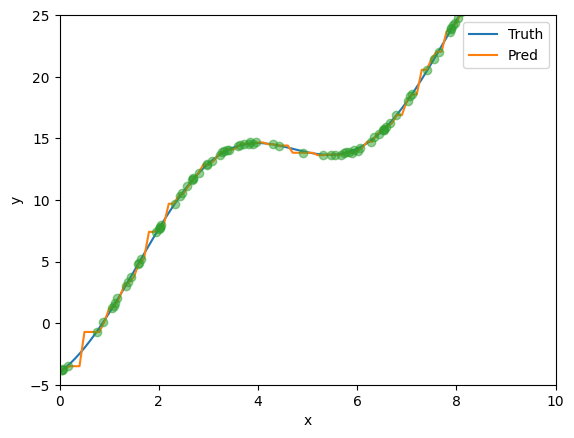

In [361]:
# Shape of `keys` is: (`n_test`, `n_train`), where each column contains the same
# training inputs (i.e., same keys)
keys = x_train.repeat((n_test, 1))
# Shape of `value` is: (`n_test`, `n_train`)
values = y_train.repeat((n_test, 1))
y_hat = net(x_test, keys, values).unsqueeze(1).detach()
plot_kernel_reg(y_hat)

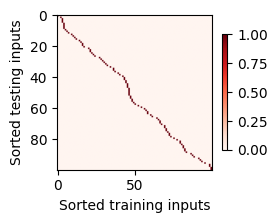

In [362]:
show_heatmaps(net.attention_weights.unsqueeze(0).unsqueeze(0),
              xlabel='Sorted training inputs',
              ylabel='Sorted testing inputs')

Exercitiul 2

In [391]:
import torch
from torch import nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import math
import os
import requests
import zipfile
import collections

torch.manual_seed(42);

In [392]:
def sequence_mask(X, valid_len, value=0):
    """Mask irrelevant entries in sequences."""
    maxlen = X.size(1)
    mask = torch.arange((maxlen), dtype=torch.float32,
                        device=X.device)[None, :] < valid_len[:, None]
    X[~mask] = value
    return X

In [393]:
def masked_softmax(X, valid_lens):
    """Perform softmax operation by masking elements on the last axis."""
    # `X`: 3D tensor, `valid_lens`: 1D or 2D tensor
    if valid_lens is None:
        return nn.functional.softmax(X, dim=-1)
    else:
        shape = X.shape
        if valid_lens.dim() == 1:
            valid_lens = torch.repeat_interleave(valid_lens, shape[1])
        else:
            valid_lens = valid_lens.reshape(-1)
        # On the last axis, replace masked elements with a very large negative
        # value, whose exponentiation outputs 0
        X = sequence_mask(X.reshape(-1, shape[-1]), valid_lens,
                          value=-1e6)
        return F.softmax(X.reshape(shape), dim=-1)

In [394]:
class AdditiveAttention(nn.Module):
    """Additive attention."""
    def __init__(self, key_size, query_size, num_hiddens, dropout, **kwargs):
        super(AdditiveAttention, self).__init__(**kwargs)
        self.W_k = nn.Linear(key_size, num_hiddens, bias=False)
        self.W_q = nn.Linear(query_size, num_hiddens, bias=False)
        self.w_v = nn.Linear(num_hiddens, 1, bias=False)
        self.dropout = nn.Dropout(dropout)

    def forward(self, queries, keys, values, valid_lens):
        queries, keys = self.W_q(queries), self.W_k(keys)
        # After dimension expansion, shape of `queries` is: (`batch_size`, no.
        # of queries, 1, `num_hiddens`) and shape of `keys` is: (`batch_size`,
        # 1, no. of key-value pairs, `num_hiddens`). Sum them up with
        # broadcasting
        features = queries.unsqueeze(2) + keys.unsqueeze(1)
        features = torch.tanh(features)
        # There is only one output of `self.w_v`, so we remove the last
        # one-dimensional entry from the shape. Shape of `scores` is:
        # (`batch_size`, no. of queries, no. of key-value pairs)
        scores = self.w_v(features).squeeze(-1)
        self.attention_weights = masked_softmax(scores, valid_lens)
        # Shape of `values` is: (`batch_size`, no. of key-value pairs, value
        # dimension)
        return torch.bmm(self.dropout(self.attention_weights), values)

In [395]:
class DotProductAttention(nn.Module):
    """Scaled dot product attention."""
    def __init__(self, dropout, **kwargs):
        super(DotProductAttention, self).__init__(**kwargs)
        self.dropout = nn.Dropout(dropout)

    # Shape of `queries` is: (`batch_size`, no. of queries, `d`)
    # Shape of `keys` is: (`batch_size`, no. of key-value pairs, `d`)
    # Shape of `values` is: (`batch_size`, no. of key-value pairs, value
    # dimension)
    # Shape of `valid_lens`: (`batch_size`,) or (`batch_size`, no. of queries)
    def forward(self, queries, keys, values, valid_lens=None):
        d = queries.shape[-1]
        # Use `keys.transpose(1,2)` to swap the last two dimensions of `keys`
        scores = torch.bmm(queries, keys.transpose(1,2)) / math.sqrt(d)
        self.attention_weights = masked_softmax(scores, valid_lens)
        return torch.bmm(self.dropout(self.attention_weights), values)

In [396]:
class Decoder(nn.Module):
    """The base decoder interface for the encoder-decoder architecture."""
    def __init__(self, **kwargs):
        super(Decoder, self).__init__(**kwargs)

    def init_state(self, enc_outputs, *args):
        raise NotImplementedError

    def forward(self, X, state):
        raise NotImplementedError

In [397]:
class AttentionDecoder(Decoder):
    """The base attention-based decoder interface."""
    def __init__(self, **kwargs):
        super(AttentionDecoder, self).__init__(**kwargs)

    @property
    def attention_weights(self):
        raise NotImplementedError

In [398]:
class Seq2SeqAttentionDecoder(AttentionDecoder):
    def __init__(self, vocab_size, embed_size, num_hiddens, num_layers,
                 dropout=0, **kwargs):
        super(Seq2SeqAttentionDecoder, self).__init__(**kwargs)
        self.attention = AdditiveAttention(
            num_hiddens, num_hiddens, num_hiddens, dropout)
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.rnn = nn.GRU(
            embed_size + num_hiddens, num_hiddens, num_layers,
            dropout=dropout)
        self.dense = nn.Linear(num_hiddens, vocab_size)

    def init_state(self, enc_outputs, enc_valid_lens, *args):
        # Shape of `outputs` is: (`num_steps`, `batch_size`, `num_hiddens`).
        # Shape of `hidden_state[0]` is: (`num_layers`, `batch_size`,
        # `num_hiddens`)
        outputs, hidden_state = enc_outputs
        return (outputs.permute(1, 0, 2), hidden_state, enc_valid_lens)

    def forward(self, X, state):
        # Shape of `enc_outputs` is: (`batch_size`, `num_steps`, `num_hiddens`).
        # Shape of `hidden_state[0]` is: (`num_layers`, `batch_size`,
        # `num_hiddens`)
        enc_outputs, hidden_state, enc_valid_lens = state
        # Shape of the output `X` is: (`num_steps`, `batch_size`, `embed_size`)
        X = self.embedding(X).permute(1, 0, 2)
        outputs, self._attention_weights = [], []
        for x in X:
            # Shape of `query` is: (`batch_size`, 1, `num_hiddens`)
            query = torch.unsqueeze(hidden_state[-1], dim=1)
            # Shape of `context` is: (`batch_size`, 1, `num_hiddens`)
            context = self.attention(
                query, enc_outputs, enc_outputs, enc_valid_lens)
            # Concatenate on the feature dimension
            x = torch.cat((context, torch.unsqueeze(x, dim=1)), dim=-1)
            # Reshape `x` as (1, `batch_size`, `embed_size` + `num_hiddens`)
            out, hidden_state = self.rnn(x.permute(1, 0, 2), hidden_state)
            outputs.append(out)
            self._attention_weights.append(self.attention.attention_weights)
        # After fully-connected layer transformation, shape of `outputs` is:
        # (`num_steps`, `batch_size`, `vocab_size`)
        outputs = self.dense(torch.cat(outputs, dim=0))
        return outputs.permute(1, 0, 2), [enc_outputs, hidden_state,
                                          enc_valid_lens]

    @property
    def attention_weights(self):
        return self._attention_weights

In [399]:
class Encoder(nn.Module):
    """The base encoder interface for the encoder-decoder architecture."""
    def __init__(self, **kwargs):
        super(Encoder, self).__init__(**kwargs)

    def forward(self, X, *args):
        raise NotImplementedError

class Seq2SeqEncoder(Encoder):
    """The RNN encoder for sequence to sequence learning."""
    def __init__(self, vocab_size, embed_size, num_hiddens, num_layers,
                 dropout=0, **kwargs):
        super(Seq2SeqEncoder, self).__init__(**kwargs)
        # Embedding layer
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.rnn = nn.GRU(embed_size, num_hiddens, num_layers,
                          dropout=dropout)

    def forward(self, X, *args):
        # The output `X` shape: (`batch_size`, `num_steps`, `embed_size`)
        X = self.embedding(X)
        # In RNN models, the first axis corresponds to time steps
        X = X.permute(1, 0, 2)
        # When state is not mentioned, it defaults to zeros
        output, state = self.rnn(X)
        # `output` shape: (`num_steps`, `batch_size`, `num_hiddens`)
        # `state` shape: (`num_layers`, `batch_size`, `num_hiddens`)
        return output, state

In [400]:
def try_gpu(i=0):
    """Return gpu(i) if exists, otherwise return cpu()."""
    if torch.cuda.device_count() >= i + 1:
        return torch.device(f'cuda:{i}')
    return torch.device('cpu')

In [401]:
class Vocab:
    """Vocabulary for text."""
    def __init__(self, tokens=None, min_freq=0, reserved_tokens=None):
        if tokens is None:
            tokens = []
        if reserved_tokens is None:
            reserved_tokens = []
        # Sort according to frequencies
        counter = count_corpus(tokens)
        self._token_freqs = sorted(counter.items(), key=lambda x: x[1],
                                   reverse=True)
        # The index for the unknown token is 0
        self.idx_to_token = ['<unk>'] + reserved_tokens
        self.token_to_idx = {token: idx
                             for idx, token in enumerate(self.idx_to_token)}
        for token, freq in self._token_freqs:
            if freq < min_freq:
                break
            if token not in self.token_to_idx:
                self.idx_to_token.append(token)
                self.token_to_idx[token] = len(self.idx_to_token) - 1

    def __len__(self):
        return len(self.idx_to_token)

    def __getitem__(self, tokens):
        if not isinstance(tokens, (list, tuple)):
            return self.token_to_idx.get(tokens, self.unk)
        return [self.__getitem__(token) for token in tokens]

    def to_tokens(self, indices):
        if not isinstance(indices, (list, tuple)):
            return self.idx_to_token[indices]
        return [self.idx_to_token[index] for index in indices]

    @property
    def unk(self):  # Index for the unknown token
        return 0

    @property
    def token_freqs(self):  # Token frequencies
        return self._token_freqs

def count_corpus(tokens):
    """Count token frequencies."""
    # Here `tokens` is a 1D list or 2D list
    if len(tokens) == 0 or isinstance(tokens[0], list):
        # Flatten a list of token lists into a list of tokens
        tokens = [token for line in tokens for token in line]
    return collections.Counter(tokens)

def download(url, cache_dir=os.path.join('..', 'data')):
    """Download a file, return the local filename."""
    os.makedirs(cache_dir, exist_ok=True)
    fname = os.path.join(cache_dir, url.split('/')[-1])
    if os.path.exists(fname):
        with open(fname, 'rb') as f:
            while True:
                data = f.read(1048576)
                if not data:
                    break
        return fname
    print(f'Downloading {fname} from {url}...')
    r = requests.get(url, stream=True, verify=True)
    with open(fname, 'wb') as f:
        f.write(r.content)
    return fname

def download_extract(url, folder=None):
    """Download and extract a zip file."""
    fname = download(url)
    base_dir = os.path.dirname(fname)
    data_dir, ext = os.path.splitext(fname)
    if ext == '.zip':
        fp = zipfile.ZipFile(fname, 'r')
    else:
        assert False, 'Only zip files can be extracted.'
    fp.extractall(base_dir)
    return os.path.join(base_dir, folder) if folder else data_dir

def read_data_nmt():
    """Load the English-French dataset."""
    data_dir = download_extract('http://d2l-data.s3-accelerate.amazonaws.com/fra-eng.zip')
    with open(os.path.join(data_dir, 'fra.txt'), 'r') as f:
        return f.read()

def preprocess_nmt(text):
    """Preprocess the English-French dataset."""
    def no_space(char, prev_char):
        return char in set(',.!?') and prev_char != ' '

    # Replace non-breaking space with space, and convert uppercase letters to
    # lowercase ones
    text = text.replace('\u202f', ' ').replace('\xa0', ' ').lower()
    # Insert space between words and punctuation marks
    out = [' ' + char if i > 0 and no_space(char, text[i - 1]) else char
           for i, char in enumerate(text)]
    return ''.join(out)

def tokenize_nmt(text, num_examples=None):
    """Tokenize the English-French dataset."""
    source, target = [], []
    for i, line in enumerate(text.split('\n')):
        if num_examples and i > num_examples:
            break
        parts = line.split('\t')
        if len(parts) == 2:
            source.append(parts[0].split(' '))
            target.append(parts[1].split(' '))
    return source, target

def truncate_pad(line, num_steps, padding_token):
    """Truncate or pad sequences."""
    if len(line) > num_steps:
        return line[:num_steps]  # Truncate
    return line + [padding_token] * (num_steps - len(line))  # Pad

def build_array_nmt(lines, vocab, num_steps):
    """Transform text sequences of machine translation into mini-batches."""
    lines = [vocab[l] for l in lines]
    lines = [l + [vocab['<eos>']] for l in lines]
    array = torch.tensor([truncate_pad(
        l, num_steps, vocab['<pad>']) for l in lines])
    valid_len = (array != vocab['<pad>']).type(torch.int32).sum(1)
    return array, valid_len

def load_array(data_arrays, batch_size, is_train=True):
    """Construct a PyTorch data iterator."""
    dataset = torch.utils.data.TensorDataset(*data_arrays)
    return torch.utils.data.DataLoader(dataset, batch_size, shuffle=is_train)

def load_data_nmt(batch_size, num_steps, num_examples=600):
    """Return the iterator and the vocabularies of the translation dataset."""
    text = preprocess_nmt(read_data_nmt())
    source, target = tokenize_nmt(text, num_examples)
    src_vocab = Vocab(source, min_freq=2,
                          reserved_tokens=['<pad>', '<bos>', '<eos>'])
    tgt_vocab = Vocab(target, min_freq=2,
                          reserved_tokens=['<pad>', '<bos>', '<eos>'])
    src_array, src_valid_len = build_array_nmt(source, src_vocab, num_steps)
    tgt_array, tgt_valid_len = build_array_nmt(target, tgt_vocab, num_steps)
    data_arrays = (src_array, src_valid_len, tgt_array, tgt_valid_len)
    data_iter = load_array(data_arrays, batch_size)
    return data_iter, src_vocab, tgt_vocab

In [402]:
class EncoderDecoder(nn.Module):
    """The base class for the encoder-decoder architecture."""
    def __init__(self, encoder, decoder, **kwargs):
        super(EncoderDecoder, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, enc_X, dec_X, *args):
        enc_outputs = self.encoder(enc_X, *args)
        dec_state = self.decoder.init_state(enc_outputs, *args)
        return self.decoder(dec_X, dec_state)

In [403]:
class MaskedSoftmaxCELoss(nn.CrossEntropyLoss):
    """The softmax cross-entropy loss with masks."""
    # `pred` shape: (`batch_size`, `num_steps`, `vocab_size`)
    # `label` shape: (`batch_size`, `num_steps`)
    # `valid_len` shape: (`batch_size`,)
    def forward(self, pred, label, valid_len):
        weights = torch.ones_like(label)
        weights = sequence_mask(weights, valid_len)
        self.reduction='none'
        unweighted_loss = super(MaskedSoftmaxCELoss, self).forward(
            pred.permute(0, 2, 1), label)
        weighted_loss = (unweighted_loss * weights).mean(dim=1)
        return weighted_loss

def grad_clipping(net, theta):
    """Clip the gradient."""
    params = [p for p in net.parameters() if p.requires_grad]
    norm = torch.sqrt(sum(torch.sum((p.grad ** 2)) for p in params))
    if norm > theta:
        for param in params:
            param.grad[:] *= theta / norm

def train_seq2seq(net, data_iter, lr, num_epochs, tgt_vocab, device):
    """Train a model for sequence to sequence."""
    def xavier_init_weights(m):
        if type(m) == nn.Linear:
            nn.init.xavier_uniform_(m.weight)
        if type(m) == nn.GRU:
            for param in m._flat_weights_names:
                if "weight" in param:
                    nn.init.xavier_uniform_(m._parameters[param])
    net.apply(xavier_init_weights)
    net.to(device)
    optimizer = torch.optim.Adam(net.parameters(), lr=lr)
    loss = MaskedSoftmaxCELoss()
    net.train()
    train_loss_all = []
    for epoch in range(num_epochs):
        # Sum of training loss, no. of tokens
        total_loss = 0
        total_tokens = 0
        for batch in data_iter:
            optimizer.zero_grad()
            X, X_valid_len, Y, Y_valid_len = [x.to(device) for x in batch]
            bos = torch.tensor([tgt_vocab['<bos>']] * Y.shape[0],
                               device=device).reshape(-1, 1)
            dec_input = torch.cat([bos, Y[:, :-1]], 1)  # Teacher forcing
            Y_hat, _ = net(X, dec_input, X_valid_len)
            l = loss(Y_hat, Y, Y_valid_len)
            l.sum().backward()  # Make the loss scalar for `backward`
            grad_clipping(net, 1)
            num_tokens = Y_valid_len.sum()
            optimizer.step()
            with torch.no_grad():
                total_loss += l.sum()
                total_tokens += num_tokens
        if (epoch + 1) % 10 == 0:
            train_loss_all.append(total_loss / total_tokens)
    print(f'loss {total_loss / total_tokens:.3f}, device {str(device)}')

    return train_loss_all

In [404]:
def plot_loss(train_loss_all):#aici ---------------------------------- noi lucram pe gpu si incercam sa plotuim pe ceva ce trebuie cu cpu. am modificat cu geini aici
    epochs = range(10, len(train_loss_all * 10) + 1, 10)
    # Move tensors to CPU before plotting
    train_loss_all_cpu = [t.cpu() if isinstance(t, torch.Tensor) else t for t in train_loss_all]
    plt.plot(epochs, train_loss_all_cpu, 'b', label='Train loss')
    plt.title('Training loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

In [405]:
def predict_seq2seq(net, src_sentence, src_vocab, tgt_vocab, num_steps,
                    device, save_attention_weights=False):
    """Predict for sequence to sequence."""
    # Set `net` to eval mode for inference
    net.eval()
    src_tokens = src_vocab[src_sentence.lower().split(' ')] + [
        src_vocab['<eos>']]
    enc_valid_len = torch.tensor([len(src_tokens)], device=device)
    src_tokens = truncate_pad(src_tokens, num_steps, src_vocab['<pad>'])
    # Add the batch axis
    enc_X = torch.unsqueeze(
        torch.tensor(src_tokens, dtype=torch.long, device=device), dim=0)
    enc_outputs = net.encoder(enc_X, enc_valid_len)
    dec_state = net.decoder.init_state(enc_outputs, enc_valid_len)
    # Add the batch axis
    dec_X = torch.unsqueeze(torch.tensor(
        [tgt_vocab['<bos>']], dtype=torch.long, device=device), dim=0)
    output_seq, attention_weight_seq = [], []
    for _ in range(num_steps):
        Y, dec_state = net.decoder(dec_X, dec_state)
        # We use the token with the highest prediction likelihood as the input
        # of the decoder at the next time step
        dec_X = Y.argmax(dim=2)
        pred = dec_X.squeeze(dim=0).type(torch.int32).item()
        # Save attention weights
        if save_attention_weights:
            attention_weight_seq.append(net.decoder.attention_weights)
        # Once the end-of-sequence token is predicted, the generation of the
        # output sequence is complete
        if pred == tgt_vocab['<eos>']:
            break
        output_seq.append(pred)
    return ' '.join(tgt_vocab.to_tokens(output_seq)), attention_weight_seq

In [406]:
def bleu(pred_seq, label_seq, k):
    """Compute the BLEU."""
    pred_tokens, label_tokens = pred_seq.split(' '), label_seq.split(' ')
    len_pred, len_label = len(pred_tokens), len(label_tokens)
    score = math.exp(min(0, 1 - len_label / len_pred))
    for n in range(1, k + 1):
        num_matches, label_subs = 0, collections.defaultdict(int)
        for i in range(len_label - n + 1):
            label_subs[' '.join(label_tokens[i: i + n])] += 1
        for i in range(len_pred - n + 1):
            if label_subs[' '.join(pred_tokens[i: i + n])] > 0:
                num_matches += 1
                label_subs[' '.join(pred_tokens[i: i + n])] -= 1
        score *= math.pow(num_matches / (len_pred - n + 1), math.pow(0.5, n))
    return score

In [407]:
def transpose_qkv(X, num_heads):
    """Transposition for parallel computation of multiple attention heads."""
    # Shape of input `X` is:
    # (`batch_size`, no. of queries or key-value pairs, `num_hiddens`).
    # Shape of output `X` is:
    # (`batch_size`, no. of queries or key-value pairs, `num_heads`,
    # `num_hiddens` / `num_heads`)
    X = X.reshape(X.shape[0], X.shape[1], num_heads, -1)

    # Shape of output `X` is:
    # (`batch_size`, `num_heads`, no. of queries or key-value pairs,
    # `num_hiddens` / `num_heads`)
    X = X.permute(0, 2, 1, 3)

    # Shape of `output` is:
    # (`batch_size` * `num_heads`, no. of queries or key-value pairs,
    # `num_hiddens` / `num_heads`)
    return X.reshape(-1, X.shape[2], X.shape[3])

def transpose_output(X, num_heads):
    """Reverse the operation of `transpose_qkv`."""
    X = X.reshape(-1, num_heads, X.shape[1], X.shape[2])
    X = X.permute(0, 2, 1, 3)
    return X.reshape(X.shape[0], X.shape[1], -1)

In [408]:
class MultiHeadAttention(nn.Module):
    """Multi-head attention."""
    def __init__(self, key_size, query_size, value_size, num_hiddens,
                 num_heads, dropout, bias=False, **kwargs):
        super(MultiHeadAttention, self).__init__(**kwargs)
        self.num_heads = num_heads
        self.attention = DotProductAttention(dropout)
        self.W_q = nn.Linear(query_size, num_hiddens, bias=bias)
        self.W_k = nn.Linear(key_size, num_hiddens, bias=bias)
        self.W_v = nn.Linear(value_size, num_hiddens, bias=bias)
        self.W_o = nn.Linear(num_hiddens, num_hiddens, bias=bias)

    def forward(self, queries, keys, values, valid_lens):
        # Shape of `queries`, `keys`, or `values` is:
        # (`batch_size`, no. of queries or key-value pairs, `num_hiddens`)
        # Shape of `valid_lens` is:
        # (`batch_size`,) or (`batch_size`, no. of queries)
        # After transposing, shape of output `queries`, `keys`, or `values` is:
        # (`batch_size` * `num_heads`, no. of queries or key-value pairs,
        # `num_hiddens` / `num_heads`)
        queries = transpose_qkv(self.W_q(queries), self.num_heads)
        keys = transpose_qkv(self.W_k(keys), self.num_heads)
        values = transpose_qkv(self.W_v(values), self.num_heads)

        if valid_lens is not None:
            # On axis 0, copy the first item (scalar or vector) for
            # `num_heads` times, then copy the next item, and so on
            valid_lens = torch.repeat_interleave(
                valid_lens, repeats=self.num_heads, dim=0)

        # Shape of `output` is: (`batch_size` * `num_heads`, no. of queries,
        # `num_hiddens` / `num_heads`)
        output = self.attention(queries, keys, values, valid_lens)

        # Shape of `output_concat` is:
        # (`batch_size`, no. of queries, `num_hiddens`)
        output_concat = transpose_output(output, self.num_heads)
        return self.W_o(output_concat)

In [409]:
class PositionalEncoding(nn.Module):
    """Positional encoding."""
    def __init__(self, num_hiddens, dropout, max_len=1000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(dropout)
        # Create a long enough `P`
        self.P = torch.zeros((1, max_len, num_hiddens))
        X = torch.arange(max_len, dtype=torch.float32).reshape(
            -1, 1) / torch.pow(10000, torch.arange(
            0, num_hiddens, 2, dtype=torch.float32) / num_hiddens)
        self.P[:, :, 0::2] = torch.sin(X)
        self.P[:, :, 1::2] = torch.cos(X)

    def forward(self, X):
        X = X + self.P[:, :X.shape[1], :].to(X.device)
        return self.dropout(X)

In [410]:
class PositionWiseFFN(nn.Module):
    """Position-wise feed-forward network."""
    def __init__(self, ffn_num_input, ffn_num_hiddens, ffn_num_outputs,
                 **kwargs):
        super(PositionWiseFFN, self).__init__(**kwargs)
        self.dense1 = nn.Linear(ffn_num_input, ffn_num_hiddens)
        self.relu = nn.ReLU()
        self.dense2 = nn.Linear(ffn_num_hiddens, ffn_num_hiddens)
        self.dense3 = nn.Linear(ffn_num_hiddens, ffn_num_hiddens)
        self.dense4 = nn.Linear(ffn_num_hiddens, ffn_num_outputs)#aici---------------------------------------------------------

    def forward(self, X):
        return self.dense4(self.relu(self.dense3(self.relu(self.dense2(self.relu(self.dense1(X)))))))

In [411]:
class AddNorm(nn.Module):
    """Residual connection followed by layer normalization."""
    def __init__(self, normalized_shape, dropout, **kwargs):
        super(AddNorm, self).__init__(**kwargs)
        self.dropout = nn.Dropout(dropout)
        self.ln = nn.LayerNorm(normalized_shape)

    def forward(self, X, Y):
        return self.ln(self.dropout(Y) + X)

In [412]:
class EncoderBlock(nn.Module):
    """Transformer encoder block."""
    def __init__(self, key_size, query_size, value_size, num_hiddens,
                 norm_shape, ffn_num_input, ffn_num_hiddens, num_heads,
                 dropout, use_bias=False, **kwargs):
        super(EncoderBlock, self).__init__(**kwargs)
        self.attention = MultiHeadAttention(
            key_size, query_size, value_size, num_hiddens, num_heads, dropout,
            use_bias)
        self.addnorm1 = AddNorm(norm_shape, dropout)
        self.ffn = PositionWiseFFN(
            ffn_num_input, ffn_num_hiddens, num_hiddens)
        self.addnorm2 = AddNorm(norm_shape, dropout)

    def forward(self, X, valid_lens):
        Y = self.addnorm1(X, self.attention(X, X, X, valid_lens))
        return self.addnorm2(Y, self.ffn(Y))

In [413]:
class TransformerEncoder(Encoder):
    """Transformer encoder."""
    def __init__(self, vocab_size, key_size, query_size, value_size,
                 num_hiddens, norm_shape, ffn_num_input, ffn_num_hiddens,
                 num_heads, num_layers, dropout, use_bias=False, **kwargs):
        super(TransformerEncoder, self).__init__(**kwargs)
        self.num_hiddens = num_hiddens
        self.embedding = nn.Embedding(vocab_size, num_hiddens)
        self.pos_encoding = PositionalEncoding(num_hiddens, dropout)
        self.blks = nn.Sequential()
        for i in range(num_layers):
            self.blks.add_module("block"+str(i),
                EncoderBlock(key_size, query_size, value_size, num_hiddens,
                             norm_shape, ffn_num_input, ffn_num_hiddens,
                             num_heads, dropout, use_bias))

    def forward(self, X, valid_lens, *args):
        # Since positional encoding values are between -1 and 1, the embedding
        # values are multiplied by the square root of the embedding dimension
        # to rescale before they are summed up
        X = self.pos_encoding(self.embedding(X) * math.sqrt(self.num_hiddens))
        self.attention_weights = [None] * len(self.blks)
        for i, blk in enumerate(self.blks):
            X = blk(X, valid_lens)
            self.attention_weights[
                i] = blk.attention.attention.attention_weights
        return X

In [414]:
class DecoderBlock(nn.Module):
    # The `i`-th block in the decoder
    def __init__(self, key_size, query_size, value_size, num_hiddens,
                 norm_shape, ffn_num_input, ffn_num_hiddens, num_heads,
                 dropout, i, **kwargs):
        super(DecoderBlock, self).__init__(**kwargs)
        self.i = i
        self.attention1 = MultiHeadAttention(
            key_size, query_size, value_size, num_hiddens, num_heads, dropout)
        self.addnorm1 = AddNorm(norm_shape, dropout)
        self.attention2 = MultiHeadAttention(
            key_size, query_size, value_size, num_hiddens, num_heads, dropout)
        self.addnorm2 = AddNorm(norm_shape, dropout)
        self.ffn = PositionWiseFFN(ffn_num_input, ffn_num_hiddens,
                                   num_hiddens)
        self.addnorm3 = AddNorm(norm_shape, dropout)

    def forward(self, X, state):
        enc_outputs, enc_valid_lens = state[0], state[1]
        # During training, all the tokens of any output sequence are processed
        # at the same time, so `state[2][self.i]` is `None` as initialized.
        # When decoding any output sequence token by token during prediction,
        # `state[2][self.i]` contains representations of the decoded output at
        # the `i`-th block up to the current time step
        if state[2][self.i] is None:
            key_values = X
        else:
            key_values = torch.cat((state[2][self.i], X), axis=1)
        state[2][self.i] = key_values
        if self.training:
            batch_size, num_steps, _ = X.shape
            # Shape of `dec_valid_lens` is: (`batch_size`, `num_steps`), where
            # every row is [1, 2, ..., `num_steps`]
            dec_valid_lens = torch.arange(
                1, num_steps + 1, device=X.device).repeat(batch_size, 1)
        else:
            dec_valid_lens = None

        # Self-attention
        X2 = self.attention1(X, key_values, key_values, dec_valid_lens)
        Y = self.addnorm1(X, X2)
        # Encoder-decoder attention. Shape of `enc_outputs` is:
        # (`batch_size`, `num_steps`, `num_hiddens`)
        Y2 = self.attention2(Y, enc_outputs, enc_outputs, enc_valid_lens)
        Z = self.addnorm2(Y, Y2)
        return self.addnorm3(Z, self.ffn(Z)), state

In [415]:
class TransformerDecoder(AttentionDecoder):
    def __init__(self, vocab_size, key_size, query_size, value_size,
                 num_hiddens, norm_shape, ffn_num_input, ffn_num_hiddens,
                 num_heads, num_layers, dropout, **kwargs):
        super(TransformerDecoder, self).__init__(**kwargs)
        self.num_hiddens = num_hiddens
        self.num_layers = num_layers
        self.embedding = nn.Embedding(vocab_size, num_hiddens)
        self.pos_encoding = PositionalEncoding(num_hiddens, dropout)
        self.blks = nn.Sequential()
        for i in range(num_layers):
            self.blks.add_module("block"+str(i),
                DecoderBlock(key_size, query_size, value_size, num_hiddens,
                             norm_shape, ffn_num_input, ffn_num_hiddens,
                             num_heads, dropout, i))
        self.dense = nn.Linear(num_hiddens, vocab_size)

    def init_state(self, enc_outputs, enc_valid_lens, *args):
        return [enc_outputs, enc_valid_lens, [None] * self.num_layers]

    def forward(self, X, state):
        X = self.pos_encoding(self.embedding(X) * math.sqrt(self.num_hiddens))
        self._attention_weights = [[None] * len(self.blks) for _ in range (2)]
        for i, blk in enumerate(self.blks):
            X, state = blk(X, state)
            # Decoder self-attention weights
            self._attention_weights[0][
                i] = blk.attention1.attention.attention_weights
            # Encoder-decoder attention weights
            self._attention_weights[1][
                i] = blk.attention2.attention.attention_weights
        return self.dense(X), state

    @property
    def attention_weights(self):
        return self._attention_weights

loss 0.296, device cuda:0


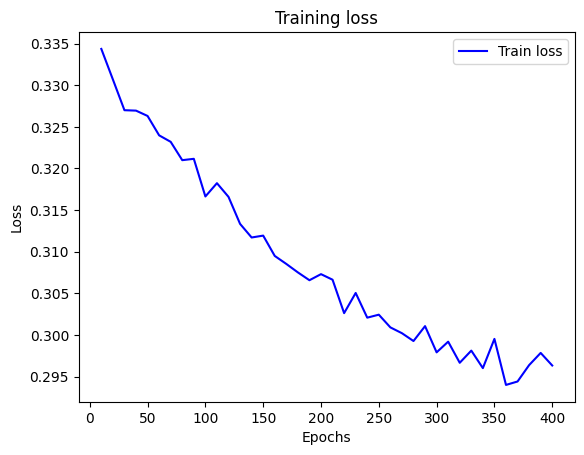

In [416]:
num_hiddens, num_layers, dropout, batch_size, num_steps = 32, 3, 0.7, 64, 10#aicii 3 si 0.7
lr, num_epochs, device = 0.005, 400, try_gpu()#400----------------------------------
ffn_num_input, ffn_num_hiddens, num_heads = 32, 32, 4#aici 32 din mijloc
key_size, query_size, value_size = 32, 32, 32
norm_shape = [32]

train_iter, src_vocab, tgt_vocab = load_data_nmt(batch_size, num_steps)

encoder = TransformerEncoder(
    len(src_vocab), key_size, query_size, value_size, num_hiddens,
    norm_shape, ffn_num_input, ffn_num_hiddens, num_heads,
    num_layers, dropout)
decoder = TransformerDecoder(
    len(tgt_vocab), key_size, query_size, value_size, num_hiddens,
    norm_shape, ffn_num_input, ffn_num_hiddens, num_heads,
    num_layers, dropout)
net = EncoderDecoder(encoder, decoder)
train_loss_all = train_seq2seq(net, train_iter, lr, num_epochs, tgt_vocab, device) #1 min

plot_loss(train_loss_all)